In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# from collections import Counter  # to find most common words
import seaborn as sns  # at least for heatmap
import re


relativepath = 'C:\\Users\\Veronika\\DATABASES\\EnergyConsumption\\'

In [2]:
print(pd.__version__)
print(sns.__version__)

1.2.4
0.11.1


In [3]:
pd.set_option('display.max_columns', 70)

In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

In [5]:
from sklearn.dummy import DummyRegressor

In [6]:
from time import time
# import datetime

In [7]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, RidgeCV, LassoCV, SGDRegressor, ElasticNet
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline, make_union
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [8]:
import xgboost as xgb
# ModuleNotFoundError: No module named 'xgboost'
# after 'pip install' doesn't rise an error

from xgboost.sklearn import XGBRegressor
# ModuleNotFoundError: No module named 'xgboost'
# after 'pip install' doesn't rise an error

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Collecting xgboost
  Downloading xgboost-1.4.2-py3-none-win_amd64.whl (97.8 MB)
Requirement already satisfied: numpy in c:\users\veronika\anaconda3\lib\site-packages (from xgboost) (1.20.1)
Requirement already satisfied: scipy in c:\users\veronika\anaconda3\lib\site-packages (from xgboost) (1.6.2)
Installing collected packages: xgboost
Successfully installed xgboost-1.4.2
Note: you may need to restart the kernel to use updated packages.
  WARNING: Retrying (Retry(total=4, connect=None, read=None, redirect=None, status=None)) after connection broken by 'NewConnectionError('<pip._vendor.urllib3.connection.HTTPSConnection object at 0x00000231B346B0D0>: Failed to establish a new connection: [Errno 11001] getaddrinfo failed')': /packages/d4/60/845dd265c7265d3bd44906d1c15be2908ff0655b32d9000935aeaeef6677/xgboost-1.4.2-py3-none-win_amd64.whl

In [10]:
raw_data = pd.read_csv(relativepath + 'seattle_energy_predict.csv')

In [11]:
data_with_score = raw_data[raw_data.ENERGYSTARScore.notnull()]

In [12]:
data_train, data_test = train_test_split(data_with_score, test_size=0.25, random_state = 6)

# SiteEnergyUse

In [13]:
optimal_params = []

In [14]:
errors = []

In [15]:
log_errors = []

## With ENERGYSTARScore (no ENERGYSTARScoreTimesGFA)

In [16]:
target_columns = ['SiteEnergyUse']
drop_columns = ['SiteEnergyUse', 'LogSiteEnergyUse',
               'TotalGHGEmissions', 'LogGHGEmissions',
               'OSEBuildingID', 'ScoreTimesGFA']

y_train = data_train[target_columns]
y_test = data_test[target_columns]

X_train = data_train.drop(drop_columns, axis=1)
X_test = data_test.drop(drop_columns, axis=1)

y = data_with_score[target_columns]
X = data_with_score.drop(drop_columns, axis=1)

In [17]:
preprocessor1 = make_column_transformer(
    (StandardScaler(),
     X.select_dtypes(include=['int64','float64']).columns),
    (OneHotEncoder
     (categories = [data_with_score[feature].unique() for feature in X.select_dtypes(exclude=['int64','float64']).columns],
      drop='first'),
     X.select_dtypes(exclude=['int64','float64']).columns))
# if error raises, remove drop='first' from OnehotEncoder

### Baseline: dummy regressors

For dummy regressors, preprocessor isn't necessary, because target y is independent from features X.

In [18]:
model = DummyRegressor(strategy='mean')

start = time()
model.fit(X_train, y_train['SiteEnergyUse'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

# to get a train score, I will form an array, length of X train, having all values equal mean of X train
y_pred_train = model.predict(X_train)

errors.append(['dummy_mean', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

errors.append(['dummy_mean', 'from_train', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

### Basic regression, not regularized

In [19]:
model = make_pipeline(preprocessor1,LinearRegression())

start = time()
model.fit(X_train, y_train['SiteEnergyUse'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

print('Root mean squared error:',  round(np.sqrt(mean_squared_error(y_test, y_pred)), 3)),
print('Mean absolute error:',  round(mean_absolute_error(y_test, y_pred), 3)),
print('Model score on test set:',  model.score(X_test, y_test)),
print('Model score on training set:',model.score(X_train, y_train))
print('Fit time:', fit_time - start)

Root mean squared error: 4859991.37
Mean absolute error: 2974557.806
Model score on test set: 0.7337180862910802
Model score on training set: 0.8002955605468702
Fit time: 0.024013519287109375


### Basic linear regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [20]:
pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=LinearRegression(), 
                          param_grid={}, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

In [21]:
y_pred = model.predict(X_test)

In [22]:
errors.append(['LR_simple', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),  # model.score(X_test, y_test) - it's a MAE now, because I set it in refit,
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [23]:
errors.append(['LR_simple', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Ridge regression illustration: manual choice of alpha

Please note: here the test set is used for the choice of hyperparameter, but it's because this section is only for demonstration of principle and illustration. The resulting model hasn't entered in the results comparison.

The Ridge Model for for models performance comparison selected alpha parameter only on train set.

In [24]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [25]:
n_alphas = 50
alphas = np.logspace(-1, 4, n_alphas)

ridge = Ridge()
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Ridge = []
errors_Ridge = []
for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X1, y_train['SiteEnergyUse'])
    coefs_Ridge.append(ridge.coef_)
#     errors_Ridge.append(np.mean((ridge.predict(X2) - y_test['SiteEnergyUse']) ** 2).values[0])
    errors_Ridge.append(np.sqrt(np.mean((ridge.predict(X2) - y_test['SiteEnergyUse']) ** 2)))
#     it's the way to calculate mean squared error

Sometimes we see that the curve (Ridge error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Ridge Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

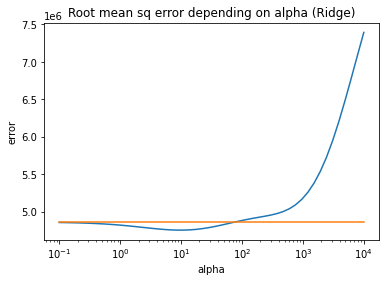

In [26]:
ax = plt.gca()

ax.plot(alphas, errors_Ridge)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Ridge)')
plt.show()

In [27]:
print('the minimal errors_Ridge is', min(errors_Ridge), 'in position', errors_Ridge.index(min(errors_Ridge)))
print('alpha parameter for the minimal error is', alphas[errors_Ridge.index(min(errors_Ridge))])

the minimal errors_Ridge is 4752840.877632881 in position 19
alpha parameter for the minimal error is 8.685113737513529


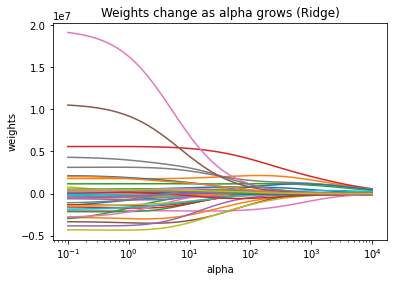

In [28]:
ax = plt.gca()

ax.plot(alphas, coefs_Ridge)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Ridge)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the ridge calculation below

### Lasso regression illustration: manual choice of alpha

Please note: here the test set is used for the choice of hyperparameter, but it's because this section is only for demonstration of principle and illustration. The resulting model hasn't entered in the results comparison.

The Lasso Model for for models performance comparison selected alpha parameter only on train set.

In [29]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [30]:
n_alphas = 50
alphas = np.logspace(2, 8, n_alphas)

lasso = Lasso(max_iter=10_000)
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Lasso = []
errors_Lasso = []
for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X1, y_train['SiteEnergyUse'])
    coefs_Lasso.append(lasso.coef_)
#     errors_Lasso.append(np.mean((lasso.predict(X2) - y_test['SiteEnergyUse']) ** 2).values[0])
    errors_Lasso.append(np.sqrt(np.mean((lasso.predict(X2) - y_test['SiteEnergyUse']) ** 2)))
#     it's the way to calculate mean squared error

Sometimes we see that the curve (Lasso error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Lasso Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

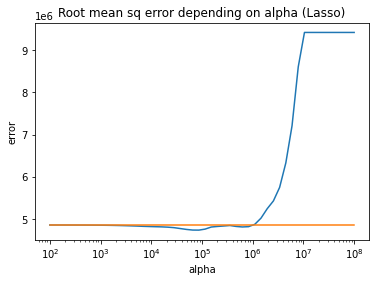

In [31]:
ax = plt.gca()

ax.plot(alphas, errors_Lasso)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Lasso)')
plt.show()

In [32]:
print('the minimal errors_Lasso is', min(errors_Lasso), 'in position', errors_Lasso.index(min(errors_Lasso)))
print('alpha parameter for the minimal error is', alphas[errors_Lasso.index(min(errors_Lasso))])

the minimal errors_Lasso is 4738637.1474289745 in position 24
alpha parameter for the minimal error is 86851.13737513521


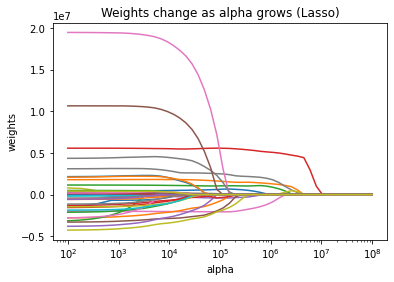

In [33]:
ax = plt.gca()

ax.plot(alphas, coefs_Lasso)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Lasso)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the lasso calculation below

### Ridge regression with cross-validation

There is an implemented function for cross-validation in Ridge regression, called RidgeCV.

This implementation doesn't allow use multiple scores:

ValueError: For multi-metric scoring, the parameter refit must be set to a scorer key or a callable to refit an estimator with the best parameter setting on the whole data and make the best_* attributes available for that metric. If this is not needed, refit should be set to False explicitly. True was passed.

When I add the refit parameter, another error raises:

TypeError: __init__() got an unexpected keyword argument 'refit'

So for my purposes of multiple metrics, I will use standart Ridge with GridSearch

In [34]:
param_test = {'alpha': np.logspace(-1, 3, 10)}

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Ridge(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_ridge.py:555: UserWarning: "sag" solver requires many iterations to fit an intercept with sparse inputs. Either set the solver to "auto" or "sparse_cg", or set a low "tol" and a high "max_iter" (especially if inputs are not standardized).

'sag' solver was removed from the parameters grid.

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: 

I have just kept only 'auto' solver.

In [35]:
# tygdyk
model[1].best_params_

{'alpha': 2.1544346900318834}

In [36]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Ridge'
optimal_params.append(['Ridge', param_stock])

In [37]:
y_pred = model.predict(X_test)

errors.append(['Ridge', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [38]:
errors.append(['Ridge', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Lasso regression with cross-validation

There is an implemented function for cross-validation in Lasso regression, called LassoCV.

This implementation doesn't allow using multiple scores, and, unlike RidgeCV above, it doesn't allow to choose the score. It minimizes the optimization function (mean_squared error + alpha * |L1|.

In [39]:
np.logspace(-3, 5, 9)

array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04,
       1.e+05])

In [40]:
param_test = {'alpha': np.logspace(-3, 5, 9),
#               'precompute': [False, True],  # default parameter False is better for all the test I did
             'selection': ['random', 'cyclic']}


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Lasso(tol=1, max_iter = 1000_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error'))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

In [41]:
# tygdyk
model[1].best_params_

{'alpha': 10000.0, 'selection': 'cyclic'}

The alpha parameter is different with every click!

When I launch the Lasso model several times in circle, I observe whatever alpha parameters from 0.0001 to 100000!
Maybe it depends on data splits during cross-validation, because all the parameters stay intact.

Maybe the varied results are due to high tolerance? But when I tried to use the standard value 10**-4 for tolerance, even 1000000 iterations is not enough! The warning rises that the function did not converge.

In [42]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Lasso'
optimal_params.append(['Lasso', param_stock])

In [43]:
y_pred = model.predict(X_test)

errors.append(['Lasso', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [44]:
errors.append(['Lasso', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Elastic Net regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [45]:
param_test = {'alpha': np.logspace(-3, 3, 7),
             'l1_ratio': np.linspace(0.1, 0.9, 9),
#              'selection': ['random', 'cyclic']
             }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=ElasticNet(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

for each of RMSE, MAE and R2 score

In [46]:
# tygdyk
model[1].best_params_

{'alpha': 0.01, 'l1_ratio': 0.9}

In [47]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Elastic Net'
optimal_params.append(['Elastic Net', param_stock])

In [48]:
y_pred = model.predict(X_test)

errors.append(['ElasticNet', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [49]:
errors.append(['ElasticNet', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Random Forest Regressor with cross-validation

In [50]:
param_test = {'n_estimators': [100, 200, 400, 600], # of best value is 400, sometimes 200
#              'criterion': ['mse', 'mae'],  # default value is mse
#              'max_depth': [4, 6, 9, None], # default value None is the best for most part of the tests
#              'min_samples_split': [2, 5, 20],  # default value 2 is the best
#              'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#              'min_weight_fraction_leaf': [0, 0.1], # default value 0 is the best
#              'max_features': ['auto', 'sqrt'], # default value 'auto' is the best, 'log' rises an error, model not converged
#              'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
             'min_impurity_decrease': [0, 0.1, 1],  # best param varies from one click to another
#              'verbose': [0],
#              'ccp_alpha': [0],  # should be non-negative
#              'max_samples': [None, 900]  #if take less than None, model doesn't converge
             }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=RandomForestRegressor(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:880: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

In [51]:
# tygdyk
model[1].best_params_

{'min_impurity_decrease': 0, 'n_estimators': 400}

In [52]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [53]:
y_pred = model.predict(X_test)

errors.append(['Random_Forest', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [54]:
errors.append(['Random_Forest', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Gradient Boosting Regressor with cross-validation

In [55]:
param_test = {'loss': ['ls', 'lad', 'huber', 'quantile'], # huber is the best
#               'learning_rate': [0.2, 0.1, 0.05], # default value 0.1 is best of 0.2, 0.1, 0.05
              'n_estimators': [100, 200, 400, 600], # of best value is 400, sometimes 200
              'max_depth': [4, 6, 9, None], # default value None is the best, sometimes 4
#               'subsample': [1.0, 0.9],
#               'min_samples_split': [2, 5, 10],  # default value 2 is the best
#               'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#               'min_weight_fraction_leaf': [0, 0.1], # default value 0 is the best
#               'max_features': ['auto', 'sqrt'], # default value 'auto' is the best, 'log' rises an error, model not converged
#               'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
              'min_impurity_decrease': [1, 10, 100],  # best param varies from one click to another
              }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=GradientBoostingRegressor(n_iter_no_change=5, tol = 0.1), 
                          param_grid=param_test, 
                          cv=3, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

In [56]:
# tygdyk
model[1].best_params_

{'loss': 'ls', 'max_depth': 4, 'min_impurity_decrease': 1, 'n_estimators': 100}

In [57]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [58]:
y_pred = model.predict(X_test)

errors.append(['Gradient_Boosting', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [59]:
errors.append(['Gradient_Boosting', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

###  XGB Regressor with cross-validation, Learning API

In [60]:
prepr_fitted = preprocessor1.fit(X_train)
X1 = prepr_fitted.transform(X_train)
X2 = prepr_fitted.transform(X_test)

dtrain = xgb.DMatrix(X1, label=y_train['SiteEnergyUse'])
dtest = xgb.DMatrix(X2, label=y_test['SiteEnergyUse'])

In [61]:
# guide for parameters tuning: https://blog.cambridgespark.com/hyperparameter-tuning-in-xgboost-4ff9100a3b2f
# notice the importance of the seed

params = {
    # Parameters that we are going to tune.
    'max_depth':6,
    'min_child_weight': 1,
    'eta':.3,
    'subsample': 1,
    'colsample_bytree': 1,
    # Other parameters
    'objective':'reg:squarederror',
    'eval_metric': ['rmse', 'mae']
}
num_boost_round = 999

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/objective/regression_obj.cu:171: reg:linear is now deprecated in favor of reg:squarederror.

In [62]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:8749450.00000	Test-mae:4815249.00000
[1]	Test-rmse:6903331.00000	Test-mae:3686350.00000
[2]	Test-rmse:5469122.00000	Test-mae:2958226.00000
[3]	Test-rmse:4653464.50000	Test-mae:2547507.00000
[4]	Test-rmse:4008975.25000	Test-mae:2220992.00000
[5]	Test-rmse:3912834.50000	Test-mae:2110569.75000
[6]	Test-rmse:3713222.75000	Test-mae:2055498.25000
[7]	Test-rmse:3619204.75000	Test-mae:2025337.25000
[8]	Test-rmse:3646487.50000	Test-mae:2015107.75000
[9]	Test-rmse:3646483.75000	Test-mae:1991644.75000
[10]	Test-rmse:3628607.50000	Test-mae:1972627.12500
[11]	Test-rmse:3619579.25000	Test-mae:1966983.00000
[12]	Test-rmse:3602946.25000	Test-mae:1960508.25000
[13]	Test-rmse:3603990.75000	Test-mae:1947507.12500
[14]	Test-rmse:3618176.50000	Test-mae:1947106.62500
[15]	Test-rmse:3636500.50000	Test-mae:1946338.00000
[16]	Test-rmse:3612835.75000	Test-mae:1927269.25000
[17]	Test-rmse:3601590.00000	Test-mae:1924024.75000
[18]	Test-rmse:3599221.25000	Test-mae:1920979.12500
[19]	Test-rmse:3598905

In [63]:
print("Best MAE: {:.2f} with {} rounds".format(
                 model.best_score,
                 model.best_iteration+1))

Best MAE: 1874024.75 with 44 rounds


In [64]:
cv_results = xgb.cv(params, 
                    dtrain, 
                    num_boost_round=num_boost_round, 
                    seed=42, 
                    nfold=5, 
                    metrics={'rmse', 'mae'},  # 'r2' or 'r2score' doesn't exist
                    early_stopping_rounds=10)

In [65]:
cv_results['test-mae-mean'].min()

2183881.05

In [66]:
gridsearch_params = [
    (max_depth, min_child_weight)
    for max_depth in (2,3,6)
    for min_child_weight in np.logspace(-8, 0, 3) #in range(5,8)
]

In [67]:
# Define initial best params and MAE
min_mae = float("Inf")
min_rmse = float("Inf")
# best_params = None

for max_depth, min_child_weight in gridsearch_params:
#     print("CV with max_depth={}, min_child_weight={}".format(
#                              max_depth,
#                              min_child_weight))
    # Update our parameters
    params['max_depth'] = max_depth
    params['min_child_weight'] = min_child_weight
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best MAE
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (max_depth,min_child_weight)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: max depth {}, min child weight{}, MAE: {}, RMSE: {}".format(best_params[0], 
                                                                                best_params[1], min_mae, min_rmse))

params['max_depth'] = best_params[0]
params['min_child_weight'] = best_params[1]

Best params: max depth 3, min child weight1e-08, MAE: 2169588.025, RMSE: 5099221.15


In [68]:
gridsearch_params = [
    (subsample, colsample)
    for subsample in [i/10. for i in range(6,11,2)]
    for colsample in [i/10. for i in range(6,11,2)]
]

In [69]:
min_mae = float("Inf")
min_rmse = float("Inf")
best_params = None

# Start by the largest values and go down to the smallest
for subsample, colsample in reversed(gridsearch_params):
#     print("CV with subsample={}, colsample={}".format(
#                              subsample,
#                              colsample))

    # Update parameters
    params['subsample'] = subsample
    params['colsample_bytree'] = colsample
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (subsample,colsample)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}".format(best_params[0], best_params[1], min_mae))

params['subsample'] = best_params[0]
params['colsample_bytree'] = best_params[1]

Best params: 1.0, 0.8, MAE: 2136228.125


In [70]:
%time
min_mae = float("Inf")
best_params = None
for eta in [.3, .2, .1, .05, .01, .005]:
#     print("CV with eta={}".format(eta))
    
    # Update parameters
    params['eta'] = eta
    # Run and time CV
    %time cv_results = xgb.cv(params,dtrain,num_boost_round=num_boost_round,seed=42,nfold=5,metrics=['rmse','mae'],early_stopping_rounds=10)
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-mae-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds\n".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = eta
    if mean_mae < min_mae:
        min_mae = mean_mae
print("Best params: {}, MAE: {}, RMSE: {}".format(best_params, min_mae, min_rmse))

params['eta'] = best_params

Wall time: 0 ns
Wall time: 544 ms
Wall time: 385 ms
Wall time: 672 ms
Wall time: 2.15 s
Wall time: 4.17 s
Wall time: 4.02 s
Best params: 0.05, MAE: 2040140.15, RMSE: 4956226.05


In [71]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:11078032.00000	Test-mae:6345249.00000
[1]	Test-rmse:10659985.00000	Test-mae:6054739.00000
[2]	Test-rmse:10276609.00000	Test-mae:5791008.50000
[3]	Test-rmse:9879739.00000	Test-mae:5523019.00000
[4]	Test-rmse:9518136.00000	Test-mae:5271062.00000
[5]	Test-rmse:9136358.00000	Test-mae:5014963.50000
[6]	Test-rmse:8810845.00000	Test-mae:4810651.00000
[7]	Test-rmse:8442710.00000	Test-mae:4576982.50000
[8]	Test-rmse:8155037.50000	Test-mae:4403349.00000
[9]	Test-rmse:7850702.50000	Test-mae:4227370.00000
[10]	Test-rmse:7564498.50000	Test-mae:4052786.50000
[11]	Test-rmse:7308876.00000	Test-mae:3897238.75000
[12]	Test-rmse:7082288.50000	Test-mae:3768415.00000
[13]	Test-rmse:6876033.00000	Test-mae:3654900.50000
[14]	Test-rmse:6642236.00000	Test-mae:3530949.00000
[15]	Test-rmse:6425564.50000	Test-mae:3407325.25000
[16]	Test-rmse:6238232.00000	Test-mae:3300675.75000
[17]	Test-rmse:6064807.00000	Test-mae:3200567.25000
[18]	Test-rmse:5911131.00000	Test-mae:3115572.25000
[19]	Test-rmse:5777

[157]	Test-rmse:3361140.00000	Test-mae:1921999.12500
[158]	Test-rmse:3366611.75000	Test-mae:1922985.87500
[159]	Test-rmse:3365248.75000	Test-mae:1921862.75000
[160]	Test-rmse:3364324.75000	Test-mae:1921389.12500
[161]	Test-rmse:3363428.25000	Test-mae:1920836.12500
[162]	Test-rmse:3361788.25000	Test-mae:1919005.62500
[163]	Test-rmse:3363666.00000	Test-mae:1918872.12500
[164]	Test-rmse:3359844.50000	Test-mae:1917961.25000
[165]	Test-rmse:3358484.25000	Test-mae:1914197.87500
[166]	Test-rmse:3357667.00000	Test-mae:1913646.50000
[167]	Test-rmse:3355514.00000	Test-mae:1911658.25000
[168]	Test-rmse:3354676.25000	Test-mae:1910256.50000
[169]	Test-rmse:3353316.00000	Test-mae:1907081.00000
[170]	Test-rmse:3353292.50000	Test-mae:1906106.25000
[171]	Test-rmse:3348782.25000	Test-mae:1903903.12500
[172]	Test-rmse:3344867.50000	Test-mae:1902330.25000
[173]	Test-rmse:3342622.50000	Test-mae:1900155.12500
[174]	Test-rmse:3342174.50000	Test-mae:1900415.50000
[175]	Test-rmse:3353864.75000	Test-mae:1902238

[311]	Test-rmse:3295413.00000	Test-mae:1819756.75000
[312]	Test-rmse:3295443.50000	Test-mae:1819532.12500
[313]	Test-rmse:3284813.50000	Test-mae:1815828.87500
[314]	Test-rmse:3285928.00000	Test-mae:1816438.25000
[315]	Test-rmse:3283129.50000	Test-mae:1815068.50000
[316]	Test-rmse:3281666.50000	Test-mae:1814948.00000
[317]	Test-rmse:3281942.00000	Test-mae:1814610.25000
[318]	Test-rmse:3282601.75000	Test-mae:1814770.12500
[319]	Test-rmse:3283117.25000	Test-mae:1816256.62500
[320]	Test-rmse:3285713.25000	Test-mae:1817140.87500
[321]	Test-rmse:3282210.50000	Test-mae:1815084.50000
[322]	Test-rmse:3280476.25000	Test-mae:1814101.87500
[323]	Test-rmse:3279702.75000	Test-mae:1814332.50000
[324]	Test-rmse:3279342.75000	Test-mae:1814087.87500
[325]	Test-rmse:3278392.25000	Test-mae:1812761.00000
[326]	Test-rmse:3278168.50000	Test-mae:1812318.75000
[327]	Test-rmse:3279473.50000	Test-mae:1813018.50000
[328]	Test-rmse:3279400.25000	Test-mae:1812630.50000
[329]	Test-rmse:3281935.75000	Test-mae:1813341

In [72]:
print("Best MAE: {:.2f} in {} rounds".format(model.best_score, model.best_iteration+1))

Best MAE: 1800057.62 in 378 rounds


In [73]:
num_boost_round = model.best_iteration + 1
best_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")])

[0]	Test-rmse:11078032.00000	Test-mae:6345249.00000
[1]	Test-rmse:10659985.00000	Test-mae:6054739.00000
[2]	Test-rmse:10276609.00000	Test-mae:5791008.50000
[3]	Test-rmse:9879739.00000	Test-mae:5523019.00000
[4]	Test-rmse:9518136.00000	Test-mae:5271062.00000
[5]	Test-rmse:9136358.00000	Test-mae:5014963.50000
[6]	Test-rmse:8810845.00000	Test-mae:4810651.00000
[7]	Test-rmse:8442710.00000	Test-mae:4576982.50000
[8]	Test-rmse:8155037.50000	Test-mae:4403349.00000
[9]	Test-rmse:7850702.50000	Test-mae:4227370.00000
[10]	Test-rmse:7564498.50000	Test-mae:4052786.50000
[11]	Test-rmse:7308876.00000	Test-mae:3897238.75000
[12]	Test-rmse:7082288.50000	Test-mae:3768415.00000
[13]	Test-rmse:6876033.00000	Test-mae:3654900.50000
[14]	Test-rmse:6642236.00000	Test-mae:3530949.00000
[15]	Test-rmse:6425564.50000	Test-mae:3407325.25000
[16]	Test-rmse:6238232.00000	Test-mae:3300675.75000
[17]	Test-rmse:6064807.00000	Test-mae:3200567.25000
[18]	Test-rmse:5911131.00000	Test-mae:3115572.25000
[19]	Test-rmse:5777

[157]	Test-rmse:3361140.00000	Test-mae:1921999.12500
[158]	Test-rmse:3366611.75000	Test-mae:1922985.87500
[159]	Test-rmse:3365248.75000	Test-mae:1921862.75000
[160]	Test-rmse:3364324.75000	Test-mae:1921389.12500
[161]	Test-rmse:3363428.25000	Test-mae:1920836.12500
[162]	Test-rmse:3361788.25000	Test-mae:1919005.62500
[163]	Test-rmse:3363666.00000	Test-mae:1918872.12500
[164]	Test-rmse:3359844.50000	Test-mae:1917961.25000
[165]	Test-rmse:3358484.25000	Test-mae:1914197.87500
[166]	Test-rmse:3357667.00000	Test-mae:1913646.50000
[167]	Test-rmse:3355514.00000	Test-mae:1911658.25000
[168]	Test-rmse:3354676.25000	Test-mae:1910256.50000
[169]	Test-rmse:3353316.00000	Test-mae:1907081.00000
[170]	Test-rmse:3353292.50000	Test-mae:1906106.25000
[171]	Test-rmse:3348782.25000	Test-mae:1903903.12500
[172]	Test-rmse:3344867.50000	Test-mae:1902330.25000
[173]	Test-rmse:3342622.50000	Test-mae:1900155.12500
[174]	Test-rmse:3342174.50000	Test-mae:1900415.50000
[175]	Test-rmse:3353864.75000	Test-mae:1902238

[312]	Test-rmse:3295443.50000	Test-mae:1819532.12500
[313]	Test-rmse:3284813.50000	Test-mae:1815828.87500
[314]	Test-rmse:3285928.00000	Test-mae:1816438.25000
[315]	Test-rmse:3283129.50000	Test-mae:1815068.50000
[316]	Test-rmse:3281666.50000	Test-mae:1814948.00000
[317]	Test-rmse:3281942.00000	Test-mae:1814610.25000
[318]	Test-rmse:3282601.75000	Test-mae:1814770.12500
[319]	Test-rmse:3283117.25000	Test-mae:1816256.62500
[320]	Test-rmse:3285713.25000	Test-mae:1817140.87500
[321]	Test-rmse:3282210.50000	Test-mae:1815084.50000
[322]	Test-rmse:3280476.25000	Test-mae:1814101.87500
[323]	Test-rmse:3279702.75000	Test-mae:1814332.50000
[324]	Test-rmse:3279342.75000	Test-mae:1814087.87500
[325]	Test-rmse:3278392.25000	Test-mae:1812761.00000
[326]	Test-rmse:3278168.50000	Test-mae:1812318.75000
[327]	Test-rmse:3279473.50000	Test-mae:1813018.50000
[328]	Test-rmse:3279400.25000	Test-mae:1812630.50000
[329]	Test-rmse:3281935.75000	Test-mae:1813341.62500
[330]	Test-rmse:3281731.75000	Test-mae:1812754

In [74]:
y_pred = best_model.predict(dtest)
mean_absolute_error(y_pred, y_test)
np.sqrt(mean_squared_error(y_test, y_pred))

3265780.391886696

In [75]:
y_pred = best_model.predict(dtest)

errors.append(['XGB_LearningAPI', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               9.999])
# 

As XGBoost doesn't have R2 score in metrics in cross-validation, I calculate a train r2 score without cross-validation. 
Minimal RMSE and MAE can be found from cv_results dataframe, but the model has been updated since that: not only the parameters are optimized, but the number of iterations as well.

In [76]:
y_train_pred = best_model.predict(dtrain)

errors.append(['XGB_LearningAPI', 'from_train', 'with_score',
               round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 3),
               round(mean_absolute_error(y_train, y_train_pred), 3),
               round(r2_score(y_train, y_train_pred), 3),
#                model.score(X_train, y_train),
               9.999])
# 

'num_boost_round': 200 in params raises an error:

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "num_boost_round" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.

###  XGB Regressor with cross-validation, SKLearn API (wrapper)

In [77]:
y_train['SiteEnergyUse'].mean()

6765475.402561097

In [78]:
# full list of params https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.sklearn
# parameters: general ones, and divided by subcategory: https://xgboost.readthedocs.io/en/latest/parameter.html

param_test = {
           'n_estimators': [100, 200, 300], # from 100,200,500 best is 200
           'max_depth': [3, 6, 10], # by default 6, and 6 have been shown the best
#            'learning_rate': [0.3, 0.1, 0.05], # by default 0.3. tried 0.01 - it's better but much slower
#            'colsample_bytree': [0.3, 0.7], 
           'alpha': [0, 0.001, 0.01, 0.1],# by default 0, best shown 0.001, sometimes 0.01 with the same random state
           'lambda': [0, 1, 3, 5]  # default is 1, best shown 3 from 0.1,1,3
            }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=XGBRegressor(objective='reg:squarederror', base_score=y_train['SiteEnergyUse'].median()), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

In [79]:
# tygdyk
model[1].best_params_

{'alpha': 0.1, 'lambda': 3, 'max_depth': 3, 'n_estimators': 300}

In [80]:
param_stock = model[1].best_params_
# param_stock['name'] = 'XGBRegressor'
optimal_params.append(['XGBRegressor', param_stock])

In [81]:
# model[1].cv_results_ extremely long dictionary

In [82]:
y_pred = model.predict(X_test)

errors.append(['XGBRegressor', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [83]:
errors.append(['XGBRegressor', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### SGD Regressor with cross-validation (Stochastic Gradient Descent)

The gradient of the loss is estimated each sample at a time and the model is updated along the way with a decreasing strength schedule (aka learning rate).

The regularizer is a penalty added to the loss function that shrinks model parameters towards the zero vector using either the squared euclidean norm L2 or the absolute norm L1 or a combination of both (Elastic Net). If the parameter update crosses the 0.0 value because of the regularizer, the update is truncated to 0.0 to allow for learning sparse models and achieve online feature selection.

This implementation works with data represented as dense numpy arrays of floating point values for the features.

In [84]:
param_test = {
    'loss': ['squared_loss', 'huber'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': np.logspace(-3, 3, 7),
    'l1_ratio': np.linspace(0.1, 0.9, 9),
    'learning_rate': ['constant', 'invscaling', 'adaptive'], # default invscaling
    }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SGDRegressor(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

In [85]:
# tygdyk
model[1].best_params_

{'alpha': 0.001,
 'l1_ratio': 0.7000000000000001,
 'learning_rate': 'invscaling',
 'loss': 'squared_loss',
 'penalty': 'l2'}

In [86]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SGDegressor'
optimal_params.append(['SGDegressor', param_stock])

In [87]:
y_pred = model.predict(X_test)

errors.append(['SGDRegressor', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [88]:
errors.append(['SGDRegressor', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### SV Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [89]:
param_test = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
#     kernel 'precomputed' raises an error: the precomputed kernel matrix must be used
    'C': [1, 10, 100], # default is 1, best is 5 from 0.2, 1, 5
    'epsilon': [0.1, 1, 10]
     }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SVR(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

In [90]:
# tygdyk
model[1].best_params_

{'C': 100, 'epsilon': 0.1, 'kernel': 'linear'}

In [91]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SVR'
optimal_params.append(['SVR', param_stock])

In [92]:
y_pred = model.predict(X_test)

errors.append(['SVR', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [93]:
errors.append(['SVR', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

## Set the logarithm of SiteEnergyUse as target column

In [94]:
target_columns = ['LogSiteEnergyUse']
drop_columns = ['SiteEnergyUse', 'LogSiteEnergyUse',
               'TotalGHGEmissions', 'LogGHGEmissions',
               'OSEBuildingID', 'ScoreTimesGFA']

y_train = data_train[target_columns]
y_train_exp = data_train['SiteEnergyUse']
y_test = data_test[target_columns]
y_test_exp = data_test['SiteEnergyUse']

X_train = data_train.drop(drop_columns, axis=1)
X_test = data_test.drop(drop_columns, axis=1)

y = data_with_score[target_columns]
X = data_with_score.drop(drop_columns, axis=1)

### Baseline: dummy regressors

For dummy regressors, preprocessor isn't necessary, because target y is independent from features X.

R2 (coefficient of determination) regression score function.

Best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse). A constant model that always predicts the expected value of y, disregarding the input features, would get a R2 score of 0.0.

In [95]:
model = DummyRegressor(strategy='mean')

start = time()
model.fit(X_train, y_train['LogSiteEnergyUse'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

# to get a train score, I will form an array, length of X train, having all values equal median of X train
y_pred_train = model.predict(X_train)

log_errors.append(['dummy_mean', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

log_errors.append(['dummy_mean', 'from_train', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

errors.append(['dummy_mean', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Basic regression, not regularized

In [96]:
model = make_pipeline(preprocessor1,LinearRegression())

start = time()
model.fit(X_train, y_train['LogSiteEnergyUse'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

print('Root mean squared error:',  round(np.sqrt(mean_squared_error(y_test, y_pred)), 3)),
print('Mean absolute error:',  round(mean_absolute_error(y_test, y_pred), 3)),
print('Model score on test set:',  model.score(X_test, y_test)),
print('Model score on training set:',model.score(X_train, y_train))
print('Fit time:', fit_time - start)

Root mean squared error: 0.483
Mean absolute error: 0.346
Model score on test set: 0.8382635104847593
Model score on training set: 0.8703336142913969
Fit time: 0.014955520629882812


### Basic linear regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [97]:
pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=LinearRegression(), 
                          param_grid={}, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

In [98]:
log_errors.append(['LR_simple', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),  # model.score(X_test, y_test) - it's a MAE now, because I set it in refit,
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [99]:
log_errors.append(['LR_simple', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [100]:
errors.append(['LR_simple', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Ridge regression illustration: manual choice of alpha

In [101]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [102]:
n_alphas = 50
alphas = np.logspace(-1, 4, n_alphas)

ridge = Ridge()
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Ridge = []
log_errors_Ridge = []
for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X1, y_train['LogSiteEnergyUse'])
    coefs_Ridge.append(ridge.coef_)
#     log_errors_Ridge.append(np.mean((ridge.predict(X2) - y_test['LogSiteEnergyUse']) ** 2).values[0])
    log_errors_Ridge.append(np.sqrt(np.mean((ridge.predict(X1) - y_train['LogSiteEnergyUse']) ** 2)))
#     it's the way to calculate mean squared error

Sometimes we see that the curve (Ridge error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Ridge Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

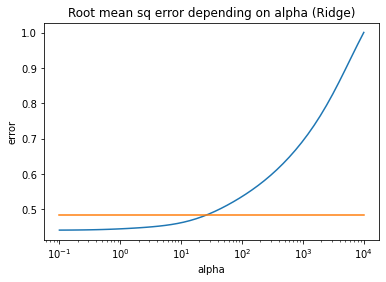

In [103]:
ax = plt.gca()

ax.plot(alphas, log_errors_Ridge)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Ridge)')
plt.show()

In [104]:
print('the minimal log_errors_Ridge is', min(log_errors_Ridge), 'in position', log_errors_Ridge.index(min(log_errors_Ridge)))
print('alpha parameter for the minimal error is', alphas[log_errors_Ridge.index(min(log_errors_Ridge))])

the minimal log_errors_Ridge is 0.4408255677836809 in position 0
alpha parameter for the minimal error is 0.1


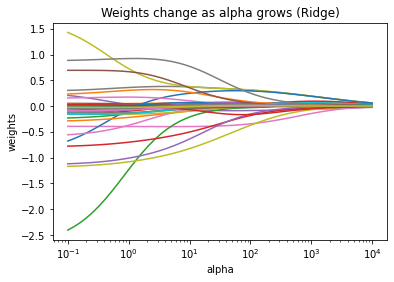

In [105]:
ax = plt.gca()

ax.plot(alphas, coefs_Ridge)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Ridge)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the ridge calculation below

### Lasso regression illustration: manual choice of alpha

In [106]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [107]:
n_alphas = 50
alphas = np.logspace(-5, 1, n_alphas)

lasso = Lasso()
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Lasso = []
log_errors_Lasso = []
for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X1, y_train['LogSiteEnergyUse'])
    coefs_Lasso.append(lasso.coef_)
#     log_errors_Lasso.append(np.mean((lasso.predict(X2) - y_test['LogSiteEnergyUse']) ** 2).values[0])
    log_errors_Lasso.append(np.sqrt(np.mean((lasso.predict(X2) - y_test['LogSiteEnergyUse']) ** 2)))
#     it's the way to calculate mean squared error

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 80.25524033097712, tolerance: 0.13088466080791925
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 78.77866223396383, tolerance: 0.13088466080791925
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 76.85300713061717, tolerance: 0.13088466080791925
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530:

Sometimes we see that the curve (Lasso error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Lasso Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

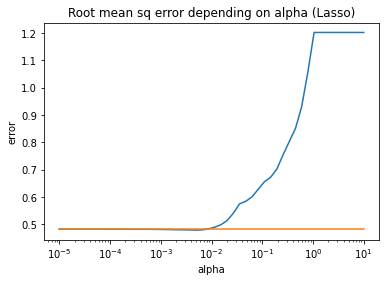

In [108]:
ax = plt.gca()

ax.plot(alphas, log_errors_Lasso)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Lasso)')
plt.show()

In [109]:
print('the minimal log_errors_Lasso is', min(log_errors_Lasso), 'in position', log_errors_Lasso.index(min(log_errors_Lasso)))
print('alpha parameter for the minimal error is', alphas[log_errors_Lasso.index(min(log_errors_Lasso))])

the minimal log_errors_Lasso is 0.4791012652524498 in position 22
alpha parameter for the minimal error is 0.004941713361323833


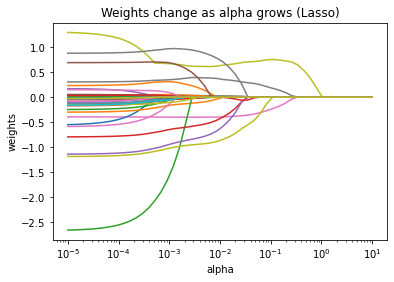

In [110]:
ax = plt.gca()

ax.plot(alphas, coefs_Lasso)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Lasso)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the lasso calculation below

### Ridge regression with cross-validation

In [111]:
param_test = {'alpha': np.logspace(-2, 1, 10)}

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Ridge(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_ridge.py:555: UserWarning: "sag" solver requires many iterations to fit an intercept with sparse inputs. Either set the solver to "auto" or "sparse_cg", or set a low "tol" and a high "max_iter" (especially if inputs are not standardized).

'sag' solver was removed from the parameters grid.

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: 

I have just kept only 'auto' solver.

In [112]:
# tygdyk
model[1].best_params_

{'alpha': 2.154434690031882}

In [113]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Ridge'
optimal_params.append(['Ridge', param_stock])

In [114]:
y_pred = model.predict(X_test)

log_errors.append(['Ridge', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [115]:
log_errors.append(['Ridge', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [116]:
errors.append(['Ridge', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Lasso regression with cross-validation

In [117]:
param_test = {'alpha': np.logspace(-4, 2, 7),
             'selection': ['random', 'cyclic']
             }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Lasso(tol=0.001, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

In [118]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'selection': 'cyclic'}

In [119]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Lasso'
optimal_params.append(['Lasso', param_stock])

In [120]:
y_pred = model.predict(X_test)

log_errors.append(['Lasso', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [121]:
log_errors.append(['Lasso', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [122]:
errors.append(['Lasso', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Elastic Net regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [123]:
param_test = {'alpha': np.logspace(-3, 3, 7),
             'l1_ratio': np.linspace(0.1, 0.9, 9),
#              'selection': ['random', 'cyclic']
             }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=ElasticNet(max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

for each of RMSE, MAE and R2 score

In [124]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'l1_ratio': 0.9}

In [125]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Elastic Net'
optimal_params.append(['Elastic Net', param_stock])

In [126]:
y_pred = model.predict(X_test)

log_errors.append(['ElasticNet', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [127]:
log_errors.append(['ElasticNet', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [128]:
errors.append(['ElasticNet', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Random Forest Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [129]:
param_test = {'n_estimators': [50, 100, 200, 400], # of 50,100,200,400 best value is 200
#              'criterion': ['mse', 'mae'],  # default value is mse
             'max_depth': [4, 6, 9, None], 
#              'min_samples_split': [2, 4],  # default value 2 is the best
#              'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#              'min_weight_fraction_leaffloat': [0], 
#              'max_features': ['auto', 'sqrt', 'log'], # default value 'auto' is the best, = n_features
#              'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
#              'min_impurity_decrease'[0], 
#              'verbose': [0],
#              'ccp_alpha': [0],  # should be non-negative
#              'max_samples': [None]  #if None, draw X.shape[0] samples
             }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=RandomForestRegressor(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:880: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

In [130]:
# tygdyk
model[1].best_params_

{'max_depth': None, 'n_estimators': 100}

In [131]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [132]:
y_pred = model.predict(X_test)

log_errors.append(['Random_Forest', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [133]:
log_errors.append(['Random_Forest', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [134]:
errors.append(['Random_Forest', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Gradient Boosting Regressor with cross-validation

In [135]:
param_test = {'loss': ['ls', 'lad', 'huber', 'quantile'], # huber is the best
#               'learning_rate': [0.2, 0.1, 0.05], # default value 0.1 is best of 0.2, 0.1, 0.05
              'n_estimators': [100, 200, 400, 600], # of best value is 400, sometimes 200
              'max_depth': [4, 6, 9, None], # default value None is the best, sometimes 4
#               'subsample': [1.0, 0.9],
#               'min_samples_split': [2, 5, 10],  # default value 2 is the best
#               'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#               'min_weight_fraction_leaf': [0, 0.1], # default value 0 is the best
#               'max_features': ['auto', 'sqrt'], # default value 'auto' is the best, 'log' rises an error, model not converged
#               'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
              'min_impurity_decrease': [0.001, 0.01, 0.1, 1],  # best param varies from one click to another
              }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=GradientBoostingRegressor(n_iter_no_change=5, tol = 0.1), 
                          param_grid=param_test, 
                          cv=3, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

In [136]:
# tygdyk
model[1].best_params_

{'loss': 'ls',
 'max_depth': 6,
 'min_impurity_decrease': 0.1,
 'n_estimators': 400}

In [137]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Gradient Boosting Regressor', param_stock])

In [138]:
y_pred = model.predict(X_test)

log_errors.append(['Gradient_Boosting', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [139]:
log_errors.append(['Gradient_Boosting', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [140]:
errors.append(['Gradient_Boosting', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

###  XGB Regressor with cross-validation, Learning API

In [141]:
prepr_fitted = preprocessor1.fit(X_train)
X1 = prepr_fitted.transform(X_train)
X2 = prepr_fitted.transform(X_test)

dtrain = xgb.DMatrix(X1, label=y_train['LogSiteEnergyUse'])
dtest = xgb.DMatrix(X2, label=y_test['LogSiteEnergyUse'])

In [142]:
# guide for parameters tuning: https://blog.cambridgespark.com/hyperparameter-tuning-in-xgboost-4ff9100a3b2f
# notice the importance of the seed

params = {
    # Parameters that we are going to tune.
    'max_depth':6,
    'min_child_weight': 1,
    'eta':.3,
    'subsample': 1,
    'colsample_bytree': 1,
    # Other parameters
    'objective':'reg:squarederror',
    'eval_metric': ['rmse', 'mae']
}
num_boost_round = 999

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/objective/regression_obj.cu:171: reg:linear is now deprecated in favor of reg:squarederror.

In [143]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:10.22776	Test-mae:10.17325
[1]	Test-rmse:7.21538	Test-mae:7.15527
[2]	Test-rmse:5.10160	Test-mae:5.03098
[3]	Test-rmse:3.64263	Test-mae:3.56198
[4]	Test-rmse:2.61021	Test-mae:2.51505
[5]	Test-rmse:1.88001	Test-mae:1.77486
[6]	Test-rmse:1.37016	Test-mae:1.26205
[7]	Test-rmse:1.03306	Test-mae:0.91908
[8]	Test-rmse:0.80694	Test-mae:0.68158
[9]	Test-rmse:0.66605	Test-mae:0.53372
[10]	Test-rmse:0.58341	Test-mae:0.45133
[11]	Test-rmse:0.53561	Test-mae:0.40862
[12]	Test-rmse:0.50032	Test-mae:0.37562
[13]	Test-rmse:0.48953	Test-mae:0.36287
[14]	Test-rmse:0.48378	Test-mae:0.35585
[15]	Test-rmse:0.47745	Test-mae:0.35055
[16]	Test-rmse:0.47514	Test-mae:0.34830
[17]	Test-rmse:0.47455	Test-mae:0.34782
[18]	Test-rmse:0.47348	Test-mae:0.34793
[19]	Test-rmse:0.47228	Test-mae:0.34745
[20]	Test-rmse:0.46985	Test-mae:0.34530
[21]	Test-rmse:0.46764	Test-mae:0.34339
[22]	Test-rmse:0.46522	Test-mae:0.34053
[23]	Test-rmse:0.46386	Test-mae:0.33892
[24]	Test-rmse:0.46442	Test-mae:0.33924
[25]	Tes

In [144]:
print("Best MAE: {:.2f} with {} rounds".format(
                 model.best_score,
                 model.best_iteration+1))

Best MAE: 0.34 with 45 rounds


In [145]:
cv_results = xgb.cv(params, 
                    dtrain, 
                    num_boost_round=num_boost_round, 
                    seed=42, 
                    nfold=5, 
                    metrics={'rmse', 'mae'},  # 'r2' or 'r2score' doesn't exist
                    early_stopping_rounds=10)

In [146]:
cv_results['test-mae-mean'].min()

0.34657560000000004

In [147]:
gridsearch_params = [
    (max_depth, min_child_weight)
    for max_depth in (2,3,6)
    for min_child_weight in np.logspace(-8, 0, 3) #in range(5,8)
]

In [148]:
# Define initial best params and MAE
min_mae = float("Inf")
min_rmse = float("Inf")
# best_params = None

for max_depth, min_child_weight in gridsearch_params:
#     print("CV with max_depth={}, min_child_weight={}".format(
#                              max_depth,
#                              min_child_weight))
    # Update our parameters
    params['max_depth'] = max_depth
    params['min_child_weight'] = min_child_weight
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best MAE
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (max_depth,min_child_weight)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}, RMSE: {}".format(best_params[0], best_params[1], min_mae, min_rmse))

params['max_depth'] = best_params[0]
params['min_child_weight'] = best_params[1]

Best params: 3, 1e-08, MAE: 0.3376848, RMSE: 0.467507


In [149]:
gridsearch_params = [
    (subsample, colsample)
    for subsample in [i/10. for i in range(6,11,2)]
    for colsample in [i/10. for i in range(6,11,2)]
]

In [150]:
min_mae = float("Inf")
min_rmse = float("Inf")
best_params = None

# Start by the largest values and go down to the smallest
for subsample, colsample in reversed(gridsearch_params):
#     print("CV with subsample={}, colsample={}".format(
#                              subsample,
#                              colsample))

    # Update parameters
    params['subsample'] = subsample
    params['colsample_bytree'] = colsample
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (subsample,colsample)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}".format(best_params[0], best_params[1], min_mae))

params['subsample'] = best_params[0]
params['colsample_bytree'] = best_params[1]

Best params: 1.0, 1.0, MAE: 0.3376848


In [151]:
%time
min_mae = float("Inf")
best_params = None
for eta in [.3, .2, .1, .05, .01, .005]:
#     print("CV with eta={}".format(eta))
    
    # Update parameters
    params['eta'] = eta
    # Run and time CV
    %time cv_results = xgb.cv(params,dtrain,num_boost_round=num_boost_round,seed=42,nfold=5,metrics=['rmse','mae'],early_stopping_rounds=10)
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-mae-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds\n".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = eta
    if mean_mae < min_mae:
        min_mae = mean_mae
print("Best params: {}, MAE: {}, RMSE: {}".format(best_params, min_mae, min_rmse))

params['eta'] = best_params

Wall time: 0 ns
Wall time: 243 ms
Wall time: 336 ms
Wall time: 745 ms
Wall time: 1.61 s
Wall time: 4.17 s
Wall time: 4.14 s
Best params: 0.05, MAE: 0.3239196, RMSE: 0.4663062


In [152]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:13.83777	Test-mae:13.78795
[1]	Test-rmse:13.15133	Test-mae:13.10107
[2]	Test-rmse:12.50159	Test-mae:12.45075
[3]	Test-rmse:11.88223	Test-mae:11.83068
[4]	Test-rmse:11.29574	Test-mae:11.24345
[5]	Test-rmse:10.73948	Test-mae:10.68704
[6]	Test-rmse:10.21066	Test-mae:10.15720
[7]	Test-rmse:9.70928	Test-mae:9.65541
[8]	Test-rmse:9.23225	Test-mae:9.17790
[9]	Test-rmse:8.78029	Test-mae:8.72531
[10]	Test-rmse:8.35016	Test-mae:8.29438
[11]	Test-rmse:7.94132	Test-mae:7.88406
[12]	Test-rmse:7.55412	Test-mae:7.49587
[13]	Test-rmse:7.18442	Test-mae:7.12525
[14]	Test-rmse:6.83428	Test-mae:6.77406
[15]	Test-rmse:6.50183	Test-mae:6.44061
[16]	Test-rmse:6.18669	Test-mae:6.12404
[17]	Test-rmse:5.88522	Test-mae:5.82123
[18]	Test-rmse:5.59878	Test-mae:5.53344
[19]	Test-rmse:5.32745	Test-mae:5.26167
[20]	Test-rmse:5.07197	Test-mae:5.00537
[21]	Test-rmse:4.82651	Test-mae:4.75824
[22]	Test-rmse:4.59550	Test-mae:4.52657
[23]	Test-rmse:4.37532	Test-mae:4.30570
[24]	Test-rmse:4.16715	Test-mae:4.09

[203]	Test-rmse:0.44653	Test-mae:0.32474
[204]	Test-rmse:0.44650	Test-mae:0.32474
[205]	Test-rmse:0.44649	Test-mae:0.32475
[206]	Test-rmse:0.44649	Test-mae:0.32480
[207]	Test-rmse:0.44630	Test-mae:0.32479
[208]	Test-rmse:0.44556	Test-mae:0.32440
[209]	Test-rmse:0.44544	Test-mae:0.32424
[210]	Test-rmse:0.44539	Test-mae:0.32417
[211]	Test-rmse:0.44537	Test-mae:0.32414
[212]	Test-rmse:0.44537	Test-mae:0.32400
[213]	Test-rmse:0.44536	Test-mae:0.32390
[214]	Test-rmse:0.44534	Test-mae:0.32395
[215]	Test-rmse:0.44540	Test-mae:0.32405
[216]	Test-rmse:0.44543	Test-mae:0.32393
[217]	Test-rmse:0.44528	Test-mae:0.32377
[218]	Test-rmse:0.44517	Test-mae:0.32361
[219]	Test-rmse:0.44513	Test-mae:0.32357
[220]	Test-rmse:0.44494	Test-mae:0.32333
[221]	Test-rmse:0.44497	Test-mae:0.32326
[222]	Test-rmse:0.44499	Test-mae:0.32327
[223]	Test-rmse:0.44432	Test-mae:0.32290
[224]	Test-rmse:0.44422	Test-mae:0.32275
[225]	Test-rmse:0.44426	Test-mae:0.32275
[226]	Test-rmse:0.44415	Test-mae:0.32243
[227]	Test-rmse:

In [153]:
print("Best MAE: {:.2f} in {} rounds".format(model.best_score, model.best_iteration+1))

Best MAE: 0.32 in 278 rounds


In [154]:
num_boost_round = model.best_iteration + 1
best_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")])

[0]	Test-rmse:13.83777	Test-mae:13.78795
[1]	Test-rmse:13.15133	Test-mae:13.10107
[2]	Test-rmse:12.50159	Test-mae:12.45075
[3]	Test-rmse:11.88223	Test-mae:11.83068
[4]	Test-rmse:11.29574	Test-mae:11.24345
[5]	Test-rmse:10.73948	Test-mae:10.68704
[6]	Test-rmse:10.21066	Test-mae:10.15720
[7]	Test-rmse:9.70928	Test-mae:9.65541
[8]	Test-rmse:9.23225	Test-mae:9.17790
[9]	Test-rmse:8.78029	Test-mae:8.72531
[10]	Test-rmse:8.35016	Test-mae:8.29438
[11]	Test-rmse:7.94132	Test-mae:7.88406
[12]	Test-rmse:7.55412	Test-mae:7.49587
[13]	Test-rmse:7.18442	Test-mae:7.12525
[14]	Test-rmse:6.83428	Test-mae:6.77406
[15]	Test-rmse:6.50183	Test-mae:6.44061
[16]	Test-rmse:6.18669	Test-mae:6.12404
[17]	Test-rmse:5.88522	Test-mae:5.82123
[18]	Test-rmse:5.59878	Test-mae:5.53344
[19]	Test-rmse:5.32745	Test-mae:5.26167
[20]	Test-rmse:5.07197	Test-mae:5.00537
[21]	Test-rmse:4.82651	Test-mae:4.75824
[22]	Test-rmse:4.59550	Test-mae:4.52657
[23]	Test-rmse:4.37532	Test-mae:4.30570
[24]	Test-rmse:4.16715	Test-mae:4.09

[203]	Test-rmse:0.44653	Test-mae:0.32474
[204]	Test-rmse:0.44650	Test-mae:0.32474
[205]	Test-rmse:0.44649	Test-mae:0.32475
[206]	Test-rmse:0.44649	Test-mae:0.32480
[207]	Test-rmse:0.44630	Test-mae:0.32479
[208]	Test-rmse:0.44556	Test-mae:0.32440
[209]	Test-rmse:0.44544	Test-mae:0.32424
[210]	Test-rmse:0.44539	Test-mae:0.32417
[211]	Test-rmse:0.44537	Test-mae:0.32414
[212]	Test-rmse:0.44537	Test-mae:0.32400
[213]	Test-rmse:0.44536	Test-mae:0.32390
[214]	Test-rmse:0.44534	Test-mae:0.32395
[215]	Test-rmse:0.44540	Test-mae:0.32405
[216]	Test-rmse:0.44543	Test-mae:0.32393
[217]	Test-rmse:0.44528	Test-mae:0.32377
[218]	Test-rmse:0.44517	Test-mae:0.32361
[219]	Test-rmse:0.44513	Test-mae:0.32357
[220]	Test-rmse:0.44494	Test-mae:0.32333
[221]	Test-rmse:0.44497	Test-mae:0.32326
[222]	Test-rmse:0.44499	Test-mae:0.32327
[223]	Test-rmse:0.44432	Test-mae:0.32290
[224]	Test-rmse:0.44422	Test-mae:0.32275
[225]	Test-rmse:0.44426	Test-mae:0.32275
[226]	Test-rmse:0.44415	Test-mae:0.32243
[227]	Test-rmse:

'num_boost_round': 200 in params raises an error:

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "num_boost_round" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.

In [155]:
y_pred = best_model.predict(dtest)
mean_absolute_error(y_pred, y_test)
np.sqrt(mean_squared_error(y_test, y_pred))

0.44160935435940507

In [156]:
y_pred = best_model.predict(dtest)

In [157]:
log_errors.append(['XGB_LearningAPI', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               9.999])

As XGBoost doesn't have R2 score in metrics in cross-validation, I calculate a train r2 score without cross-validation. 
Minimal RMSE and MAE can be found from cv_results dataframe, but the model has been updated since that: not only the parameters are optimized, but the number of iterations as well.

In [158]:
y_train_pred = best_model.predict(dtrain)

log_errors.append(['XGB_LearningAPI', 'from_train', 'with_score',
               round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 3),
               round(mean_absolute_error(y_train, y_train_pred), 3),
               round(r2_score(y_train, y_train_pred), 3),
#                model.score(X_train, y_train),
               9.999])

In [159]:
errors.append(['XGB_LearningAPI', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

###  XGB Regressor with cross-validation, SKLearn API (wrapper)

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [160]:
# question: is alpha_reg the same thing that alpha? and lambda_reg the same thing that lambda?

# params explained: https://towardsdatascience.com/xgboost-fine-tune-and-optimize-your-model-23d996fab663
# full list of params https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.sklearn
# parameters: general ones, and divided by subcategory: https://xgboost.readthedocs.io/en/latest/parameter.html

param_test = {
#            'max_depth': [3, 6, 10], # by default 6, and 6 have been shown the best
           'learning_rate': [0.01], # by default 0.3, [0.01, 0.3] 0.01 is better but much slower
           'n_estimators': [100, 500, 1000], # by default 100
#            'colsample_bytree': [0.3, 0.7], 
           'alpha': [0, 0.001, 0.01, 0.1],# by default 0, best shown 0.001
           'lambda': [1, 3, 5]  # default is 1, best shown 3 from 0.1,1,3
            }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=XGBRegressor(objective='reg:squarederror', base_score=y_train['LogSiteEnergyUse'].median()), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

In [161]:
# tygdyk
model[1].best_params_
# colsample_by_tree and n_estimators are maximal, max depth is by default 6
# {'colsample_bytree': 0.7,
#  'learning_rate': 0.01,
#  'max_depth': 6,
#  'n_estimators': 1000}

{'alpha': 0, 'lambda': 3, 'learning_rate': 0.01, 'n_estimators': 1000}

In [162]:
param_stock = model[1].best_params_
# param_stock['name'] = 'XGBRegressor'
optimal_params.append(['XGBRegressor', param_stock])

In [163]:
param_stock

{'alpha': 0, 'lambda': 3, 'learning_rate': 0.01, 'n_estimators': 1000}

In [164]:
# model[1].cv_results_ extremely long dictionary

In [165]:
y_pred = model.predict(X_test)

log_errors.append(['XGBRegressor', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [166]:
log_errors.append(['XGBRegressor', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [167]:
errors.append(['XGBRegressor', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### SGD Regressor with cross-validation (Stochastic Gradient Descent)

The gradient of the loss is estimated each sample at a time and the model is updated along the way with a decreasing strength schedule (aka learning rate).

The regularizer is a penalty added to the loss function that shrinks model parameters towards the zero vector using either the squared euclidean norm L2 or the absolute norm L1 or a combination of both (Elastic Net). If the parameter update crosses the 0.0 value because of the regularizer, the update is truncated to 0.0 to allow for learning sparse models and achieve online feature selection.

This implementation works with data represented as dense numpy arrays of floating point values for the features.

In [168]:
param_test = {
    'alpha': np.logspace(-3, 3, 7),
    'loss': ['squared_loss', 'huber'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
    'penalty': ['l2', 'l1', 'elasticnet'],
    'l1_ratio': [0.15, 0.5],
    'learning_rate': ['constant', 'invscaling', 'adaptive'], # default invscaling
    }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SGDRegressor(tol=0.001, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

In [169]:
# tygdyk
model[1].best_params_
# colsample_by_tree and n_estimators are maximal, max depth is by default 6
# {'colsample_bytree': 0.7,
#  'learning_rate': 0.01,
#  'max_depth': 6,
#  'n_estimators': 1000}

{'alpha': 0.1,
 'l1_ratio': 0.15,
 'learning_rate': 'adaptive',
 'loss': 'squared_loss',
 'penalty': 'l2'}

In [170]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SGDegressor'
optimal_params.append(['SGDegressor', param_stock])

In [171]:
y_pred = model.predict(X_test)

log_errors.append(['SGDRegressor', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [172]:
log_errors.append(['SGDRegressor', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [173]:
errors.append(['SGDRegressor', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### SV Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [174]:
param_test = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
#     kernel 'precomputed' raises an error: the precomputed kernel matrix must be used
    'C': [1, 10, 100], # default is 1, best is 5 from 0.2, 1, 5
    }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SVR(tol=0.001, max_iter=100_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

In [175]:
# tygdyk
model[1].best_params_

{'C': 1, 'kernel': 'linear'}

In [176]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SVR'
optimal_params.append(['SVR', param_stock])

In [177]:
y_pred = model.predict(X_test)

log_errors.append(['SVR', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [178]:
log_errors.append(['SVR', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [179]:
errors.append(['SVR', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

## Without ENERGYSTARScore (and no ENERGYSTARScoreTimesGFA)

In [180]:
target_columns = ['SiteEnergyUse']
drop_columns = ['SiteEnergyUse', 'LogSiteEnergyUse',
               'TotalGHGEmissions', 'LogGHGEmissions',
               'OSEBuildingID', 'ScoreTimesGFA', 'ENERGYSTARScore']

y_train = data_train[target_columns]
y_test = data_test[target_columns]

X_train = data_train.drop(drop_columns, axis=1)
X_test = data_test.drop(drop_columns, axis=1)

y = data_with_score[target_columns]
X = data_with_score.drop(drop_columns, axis=1)

In [181]:
preprocessor1 = make_column_transformer(
    (StandardScaler(),
     X.select_dtypes(include=['int64','float64']).columns),
    (OneHotEncoder
     (categories = [data_with_score[feature].unique() for feature in X.select_dtypes(exclude=['int64','float64']).columns],
      drop='first'),
     X.select_dtypes(exclude=['int64','float64']).columns))
# if error raises, remove drop='first' from OnehotEncoder

### Baseline: dummy regressors

For dummy regressors, preprocessor isn't necessary, because target y is independent from features X.

R2 (coefficient of determination) regression score function.

Best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse). A constant model that always predicts the expected value of y, disregarding the input features, would get a R2 score of 0.0.

In [182]:
model = DummyRegressor(strategy='mean')

start = time()
model.fit(X_train, y_train['SiteEnergyUse'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

# to get a train score, I will form an array, length of X train, having all values equal median of X train
y_pred_train = model.predict(X_train)

errors.append(['dummy_mean', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

errors.append(['dummy_mean', 'from_train', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

### Basic regression, not regularized

In [183]:
model = make_pipeline(preprocessor1,LinearRegression())

start = time()
model.fit(X_train, y_train['SiteEnergyUse'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

print('Root mean squared error:',  round(np.sqrt(mean_squared_error(y_test, y_pred)), 3)),
print('Mean absolute error:',  round(mean_absolute_error(y_test, y_pred), 3)),
print('Model score on test set:',  model.score(X_test, y_test)),
print('Model score on training set:',model.score(X_train, y_train))
print('Fit time:', fit_time - start)

Root mean squared error: 5107968.194
Mean absolute error: 3005496.064
Model score on test set: 0.7058512264943873
Model score on training set: 0.7741678252935136
Fit time: 0.009973287582397461


### Basic linear regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [184]:
pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=LinearRegression(), 
                          param_grid={}, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

In [185]:
y_pred = model.predict(X_test)

In [186]:
errors.append(['LR_simple', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),  # model.score(X_test, y_test) - it's a MAE now, because I set it in refit,
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [187]:
errors.append(['LR_simple', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Ridge regression with cross-validation

In [188]:
param_test = {'alpha': np.logspace(0, 3, 10)}

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Ridge(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_ridge.py:555: UserWarning: "sag" solver requires many iterations to fit an intercept with sparse inputs. Either set the solver to "auto" or "sparse_cg", or set a low "tol" and a high "max_iter" (especially if inputs are not standardized).

'sag' solver was removed from the parameters grid.

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: 

I have just kept only 'auto' solver.

In [189]:
# tygdyk
model[1].best_params_

{'alpha': 2.154434690031884}

In [190]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Ridge'
optimal_params.append(['Ridge', param_stock])

In [191]:
y_pred = model.predict(X_test)

errors.append(['Ridge', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [192]:
errors.append(['Ridge', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Lasso regression with cross-validation

In [193]:
param_test = {'alpha': np.logspace(-3, 3, 7),
#               'precompute': [False, True],  # default parameter False is better for all the test I did
             'selection': ['random', 'cyclic']}


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Lasso(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

In [194]:
# tygdyk
model[1].best_params_

{'alpha': 10.0, 'selection': 'random'}

In [195]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Lasso'
optimal_params.append(['Lasso', param_stock])

In [196]:
y_pred = model.predict(X_test)

errors.append(['Lasso', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [197]:
errors.append(['Lasso', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Elastic Net regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [198]:
param_test = {'alpha': np.logspace(-3, 3, 7),
             'l1_ratio': np.linspace(0.1, 0.9, 9),
#              'selection': ['random', 'cyclic']
             }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=ElasticNet(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

for each of RMSE, MAE and R2 score

In [199]:
# tygdyk
model[1].best_params_

{'alpha': 0.01, 'l1_ratio': 0.9}

In [200]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Elastic Net'
optimal_params.append(['Elastic Net', param_stock])

In [201]:
y_pred = model.predict(X_test)

errors.append(['ElasticNet', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [202]:
errors.append(['ElasticNet', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Random Forest Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [203]:
param_test = {'n_estimators': [50, 100, 200, 400], # of 50,100,200,400 best value is 200
#              'criterion': ['mse', 'mae'],  # default value is mse
             'max_depth': [4, 6, 9, None], 
#              'min_samples_split': [2, 4],  # default value 2 is the best
#              'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#              'min_weight_fraction_leaffloat': [0], 
#              'max_features': ['auto', 'sqrt', 'log'], # default value 'auto' is the best, = n_features
#              'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
#              'min_impurity_decrease'[0], 
#              'verbose': [0],
#              'ccp_alpha': [0],  # should be non-negative
#              'max_samples': [None]  #if None, draw X.shape[0] samples
             }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=RandomForestRegressor(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:880: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

In [204]:
# tygdyk
model[1].best_params_

{'max_depth': 9, 'n_estimators': 200}

In [205]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [206]:
y_pred = model.predict(X_test)

errors.append(['Random_Forest', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [207]:
errors.append(['Random_Forest', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Gradient Boosting Regressor with cross-validation

In [208]:
param_test = {'loss': ['ls', 'lad', 'huber', 'quantile'], # huber is the best
#               'learning_rate': [0.2, 0.1, 0.05], # default value 0.1 is best of 0.2, 0.1, 0.05
              'n_estimators': [100, 200, 400, 600], # of best value is 400, sometimes 200
              'max_depth': [4, 6, 9, None], # default value None is the best, sometimes 4
#               'subsample': [1.0, 0.9],
#               'min_samples_split': [2, 5, 10],  # default value 2 is the best
#               'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#               'min_weight_fraction_leaf': [0, 0.1], # default value 0 is the best
#               'max_features': ['auto', 'sqrt'], # default value 'auto' is the best, 'log' rises an error, model not converged
#               'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
              'min_impurity_decrease': [1, 10, 100],  # best param varies from one click to another
              }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=GradientBoostingRegressor(n_iter_no_change=5, tol = 0.1), 
                          param_grid=param_test, 
                          cv=3, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

In [209]:
# tygdyk
model[1].best_params_

{'loss': 'huber',
 'max_depth': 6,
 'min_impurity_decrease': 100,
 'n_estimators': 400}

In [210]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [211]:
y_pred = model.predict(X_test)

errors.append(['Gradient_Boosting', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [212]:
errors.append(['Gradient_Boosting', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

###  XGB Regressor with cross-validation, Learning API

In [213]:
prepr_fitted = preprocessor1.fit(X_train)
X1 = prepr_fitted.transform(X_train)
X2 = prepr_fitted.transform(X_test)

dtrain = xgb.DMatrix(X1, label=y_train['SiteEnergyUse'])
dtest = xgb.DMatrix(X2, label=y_test['SiteEnergyUse'])

In [214]:
# guide for parameters tuning: https://blog.cambridgespark.com/hyperparameter-tuning-in-xgboost-4ff9100a3b2f
# notice the importance of the seed

params = {
    # Parameters that we are going to tune.
    'max_depth':6,
    'min_child_weight': 1,
    'eta':.3,
    'subsample': 1,
    'colsample_bytree': 1,
    # Other parameters
    'objective':'reg:squarederror',
    'eval_metric': ['rmse', 'mae']
}
num_boost_round = 999

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/objective/regression_obj.cu:171: reg:linear is now deprecated in favor of reg:squarederror.

In [215]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:8785148.00000	Test-mae:4864057.50000
[1]	Test-rmse:7134263.00000	Test-mae:3835797.00000
[2]	Test-rmse:5987898.00000	Test-mae:3171801.75000
[3]	Test-rmse:5338147.50000	Test-mae:2798158.50000
[4]	Test-rmse:5036061.00000	Test-mae:2586323.00000
[5]	Test-rmse:4852112.00000	Test-mae:2522374.75000
[6]	Test-rmse:4680692.00000	Test-mae:2431859.25000
[7]	Test-rmse:4673710.50000	Test-mae:2393857.75000
[8]	Test-rmse:4740420.00000	Test-mae:2403165.00000
[9]	Test-rmse:4692124.00000	Test-mae:2404071.50000
[10]	Test-rmse:4635220.00000	Test-mae:2389912.75000
[11]	Test-rmse:4645443.50000	Test-mae:2400692.00000
[12]	Test-rmse:4690881.50000	Test-mae:2424796.75000
[13]	Test-rmse:4728156.50000	Test-mae:2438689.00000
[14]	Test-rmse:4723725.00000	Test-mae:2418419.75000
[15]	Test-rmse:4733211.50000	Test-mae:2425517.25000
[16]	Test-rmse:4770778.00000	Test-mae:2448509.00000
[17]	Test-rmse:4764254.50000	Test-mae:2444058.25000
[18]	Test-rmse:4784512.00000	Test-mae:2453201.00000
[19]	Test-rmse:4775182

In [216]:
print("Best MAE: {:.2f} with {} rounds".format(
                 model.best_score,
                 model.best_iteration+1))

Best MAE: 2389912.75 with 11 rounds


In [217]:
cv_results = xgb.cv(params, 
                    dtrain, 
                    num_boost_round=num_boost_round, 
                    seed=42, 
                    nfold=5, 
                    metrics={'rmse', 'mae'},  # 'r2' or 'r2score' doesn't exist
                    early_stopping_rounds=10)

In [218]:
cv_results['test-mae-mean'].min()

2739506.7

In [219]:
gridsearch_params = [
    (max_depth, min_child_weight)
    for max_depth in (2,3,6)
    for min_child_weight in np.logspace(-8, 0, 3) #in range(5,8)
]

In [220]:
# Define initial best params and MAE
min_mae = float("Inf")
min_rmse = float("Inf")
# best_params = None

for max_depth, min_child_weight in gridsearch_params:
#     print("CV with max_depth={}, min_child_weight={}".format(
#                              max_depth,
#                              min_child_weight))
    # Update our parameters
    params['max_depth'] = max_depth
    params['min_child_weight'] = min_child_weight
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best MAE
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (max_depth,min_child_weight)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}, RMSE: {}".format(best_params[0], best_params[1], min_mae, min_rmse))

params['max_depth'] = best_params[0]
params['min_child_weight'] = best_params[1]

Best params: 6, 1e-08, MAE: 2739506.7, RMSE: 5970628.1


In [221]:
gridsearch_params = [
    (subsample, colsample)
    for subsample in [i/10. for i in range(6,11,2)]
    for colsample in [i/10. for i in range(6,11,2)]
]

In [222]:
min_mae = float("Inf")
min_rmse = float("Inf")
best_params = None

# Start by the largest values and go down to the smallest
for subsample, colsample in reversed(gridsearch_params):
#     print("CV with subsample={}, colsample={}".format(
#                              subsample,
#                              colsample))

    # Update parameters
    params['subsample'] = subsample
    params['colsample_bytree'] = colsample
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (subsample,colsample)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}".format(best_params[0], best_params[1], min_mae))

params['subsample'] = best_params[0]
params['colsample_bytree'] = best_params[1]

Best params: 0.6, 1.0, MAE: 2666623.575


In [223]:
%time
min_mae = float("Inf")
best_params = None
for eta in [.3, .2, .1, .05, .01, .005]:
#     print("CV with eta={}".format(eta))
    
    # Update parameters
    params['eta'] = eta
    # Run and time CV
    %time cv_results = xgb.cv(params,dtrain,num_boost_round=num_boost_round,seed=42,nfold=5,metrics=['rmse','mae'],early_stopping_rounds=10)
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-mae-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds\n".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = eta
    if mean_mae < min_mae:
        min_mae = mean_mae
print("Best params: {}, MAE: {}, RMSE: {}".format(best_params, min_mae, min_rmse))

params['eta'] = best_params

Wall time: 0 ns
Wall time: 111 ms
Wall time: 144 ms
Wall time: 212 ms
Wall time: 394 ms
Wall time: 1.61 s
Wall time: 3 s
Best params: 0.005, MAE: 2557449.85, RMSE: 5911216.6


In [224]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:11486508.00000	Test-mae:6627006.00000
[1]	Test-rmse:11438214.00000	Test-mae:6596118.00000
[2]	Test-rmse:11386900.00000	Test-mae:6564535.00000
[3]	Test-rmse:11339630.00000	Test-mae:6533700.00000
[4]	Test-rmse:11295753.00000	Test-mae:6503543.00000
[5]	Test-rmse:11252301.00000	Test-mae:6472962.00000
[6]	Test-rmse:11210192.00000	Test-mae:6445137.50000
[7]	Test-rmse:11161703.00000	Test-mae:6415083.00000
[8]	Test-rmse:11113770.00000	Test-mae:6384680.50000
[9]	Test-rmse:11069043.00000	Test-mae:6355564.50000
[10]	Test-rmse:11022852.00000	Test-mae:6325985.50000
[11]	Test-rmse:10975319.00000	Test-mae:6296972.50000
[12]	Test-rmse:10931754.00000	Test-mae:6267657.00000
[13]	Test-rmse:10890345.00000	Test-mae:6240572.00000
[14]	Test-rmse:10847757.00000	Test-mae:6213458.50000
[15]	Test-rmse:10801385.00000	Test-mae:6184478.00000
[16]	Test-rmse:10759781.00000	Test-mae:6157902.50000
[17]	Test-rmse:10715596.00000	Test-mae:6129776.50000
[18]	Test-rmse:10670240.00000	Test-mae:6100595.50000
[19

[156]	Test-rmse:6601904.50000	Test-mae:3502020.75000
[157]	Test-rmse:6578500.50000	Test-mae:3489505.25000
[158]	Test-rmse:6557883.00000	Test-mae:3477558.75000
[159]	Test-rmse:6542943.50000	Test-mae:3466616.50000
[160]	Test-rmse:6524615.00000	Test-mae:3455797.50000
[161]	Test-rmse:6505563.00000	Test-mae:3443767.25000
[162]	Test-rmse:6486891.50000	Test-mae:3432331.50000
[163]	Test-rmse:6469386.00000	Test-mae:3421951.00000
[164]	Test-rmse:6449362.50000	Test-mae:3411625.50000
[165]	Test-rmse:6433834.50000	Test-mae:3401741.75000
[166]	Test-rmse:6412648.50000	Test-mae:3390941.00000
[167]	Test-rmse:6393545.50000	Test-mae:3380069.75000
[168]	Test-rmse:6373736.50000	Test-mae:3368527.00000
[169]	Test-rmse:6356477.00000	Test-mae:3358519.50000
[170]	Test-rmse:6339849.00000	Test-mae:3349019.75000
[171]	Test-rmse:6324383.50000	Test-mae:3338791.50000
[172]	Test-rmse:6303624.00000	Test-mae:3326605.00000
[173]	Test-rmse:6286857.50000	Test-mae:3317693.25000
[174]	Test-rmse:6273410.00000	Test-mae:3308129

[311]	Test-rmse:4812721.50000	Test-mae:2513648.75000
[312]	Test-rmse:4806809.00000	Test-mae:2511163.50000
[313]	Test-rmse:4801388.50000	Test-mae:2510052.50000
[314]	Test-rmse:4797785.00000	Test-mae:2508519.25000
[315]	Test-rmse:4792239.00000	Test-mae:2507173.00000
[316]	Test-rmse:4789397.00000	Test-mae:2505384.75000
[317]	Test-rmse:4783571.50000	Test-mae:2503976.50000
[318]	Test-rmse:4780161.50000	Test-mae:2501734.75000
[319]	Test-rmse:4777004.50000	Test-mae:2499772.50000
[320]	Test-rmse:4771816.50000	Test-mae:2497611.50000
[321]	Test-rmse:4768997.00000	Test-mae:2496783.75000
[322]	Test-rmse:4761848.00000	Test-mae:2494420.50000
[323]	Test-rmse:4755166.50000	Test-mae:2491663.00000
[324]	Test-rmse:4752906.00000	Test-mae:2491745.50000
[325]	Test-rmse:4748923.00000	Test-mae:2489925.25000
[326]	Test-rmse:4743739.00000	Test-mae:2487915.75000
[327]	Test-rmse:4740513.50000	Test-mae:2486242.75000
[328]	Test-rmse:4735745.50000	Test-mae:2484135.00000
[329]	Test-rmse:4728605.00000	Test-mae:2481493

[466]	Test-rmse:4347427.50000	Test-mae:2355110.50000
[467]	Test-rmse:4347631.00000	Test-mae:2354732.25000
[468]	Test-rmse:4342947.50000	Test-mae:2353542.50000
[469]	Test-rmse:4341688.00000	Test-mae:2352911.75000
[470]	Test-rmse:4341392.50000	Test-mae:2352972.50000
[471]	Test-rmse:4340464.50000	Test-mae:2352978.75000
[472]	Test-rmse:4340484.50000	Test-mae:2353549.50000
[473]	Test-rmse:4338466.00000	Test-mae:2353350.00000
[474]	Test-rmse:4337037.50000	Test-mae:2352166.50000
[475]	Test-rmse:4334388.50000	Test-mae:2351951.25000
[476]	Test-rmse:4330952.00000	Test-mae:2351558.75000
[477]	Test-rmse:4329796.00000	Test-mae:2351579.50000
[478]	Test-rmse:4327655.50000	Test-mae:2350391.00000
[479]	Test-rmse:4325512.00000	Test-mae:2350011.50000
[480]	Test-rmse:4323596.00000	Test-mae:2350495.75000
[481]	Test-rmse:4323270.00000	Test-mae:2349780.25000
[482]	Test-rmse:4324209.00000	Test-mae:2349970.50000
[483]	Test-rmse:4324592.00000	Test-mae:2349986.75000
[484]	Test-rmse:4324055.00000	Test-mae:2349927

In [225]:
print("Best MAE: {:.2f} in {} rounds".format(model.best_score, model.best_iteration+1))

Best MAE: 2349266.75 in 490 rounds


In [226]:
num_boost_round = model.best_iteration + 1
best_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")])

[0]	Test-rmse:11486508.00000	Test-mae:6627006.00000
[1]	Test-rmse:11438214.00000	Test-mae:6596118.00000
[2]	Test-rmse:11386900.00000	Test-mae:6564535.00000
[3]	Test-rmse:11339630.00000	Test-mae:6533700.00000
[4]	Test-rmse:11295753.00000	Test-mae:6503543.00000
[5]	Test-rmse:11252301.00000	Test-mae:6472962.00000
[6]	Test-rmse:11210192.00000	Test-mae:6445137.50000
[7]	Test-rmse:11161703.00000	Test-mae:6415083.00000
[8]	Test-rmse:11113770.00000	Test-mae:6384680.50000
[9]	Test-rmse:11069043.00000	Test-mae:6355564.50000
[10]	Test-rmse:11022852.00000	Test-mae:6325985.50000
[11]	Test-rmse:10975319.00000	Test-mae:6296972.50000
[12]	Test-rmse:10931754.00000	Test-mae:6267657.00000
[13]	Test-rmse:10890345.00000	Test-mae:6240572.00000
[14]	Test-rmse:10847757.00000	Test-mae:6213458.50000
[15]	Test-rmse:10801385.00000	Test-mae:6184478.00000
[16]	Test-rmse:10759781.00000	Test-mae:6157902.50000
[17]	Test-rmse:10715596.00000	Test-mae:6129776.50000
[18]	Test-rmse:10670240.00000	Test-mae:6100595.50000
[19

[156]	Test-rmse:6601904.50000	Test-mae:3502020.75000
[157]	Test-rmse:6578500.50000	Test-mae:3489505.25000
[158]	Test-rmse:6557883.00000	Test-mae:3477558.75000
[159]	Test-rmse:6542943.50000	Test-mae:3466616.50000
[160]	Test-rmse:6524615.00000	Test-mae:3455797.50000
[161]	Test-rmse:6505563.00000	Test-mae:3443767.25000
[162]	Test-rmse:6486891.50000	Test-mae:3432331.50000
[163]	Test-rmse:6469386.00000	Test-mae:3421951.00000
[164]	Test-rmse:6449362.50000	Test-mae:3411625.50000
[165]	Test-rmse:6433834.50000	Test-mae:3401741.75000
[166]	Test-rmse:6412648.50000	Test-mae:3390941.00000
[167]	Test-rmse:6393545.50000	Test-mae:3380069.75000
[168]	Test-rmse:6373736.50000	Test-mae:3368527.00000
[169]	Test-rmse:6356477.00000	Test-mae:3358519.50000
[170]	Test-rmse:6339849.00000	Test-mae:3349019.75000
[171]	Test-rmse:6324383.50000	Test-mae:3338791.50000
[172]	Test-rmse:6303624.00000	Test-mae:3326605.00000
[173]	Test-rmse:6286857.50000	Test-mae:3317693.25000
[174]	Test-rmse:6273410.00000	Test-mae:3308129

[311]	Test-rmse:4812721.50000	Test-mae:2513648.75000
[312]	Test-rmse:4806809.00000	Test-mae:2511163.50000
[313]	Test-rmse:4801388.50000	Test-mae:2510052.50000
[314]	Test-rmse:4797785.00000	Test-mae:2508519.25000
[315]	Test-rmse:4792239.00000	Test-mae:2507173.00000
[316]	Test-rmse:4789397.00000	Test-mae:2505384.75000
[317]	Test-rmse:4783571.50000	Test-mae:2503976.50000
[318]	Test-rmse:4780161.50000	Test-mae:2501734.75000
[319]	Test-rmse:4777004.50000	Test-mae:2499772.50000
[320]	Test-rmse:4771816.50000	Test-mae:2497611.50000
[321]	Test-rmse:4768997.00000	Test-mae:2496783.75000
[322]	Test-rmse:4761848.00000	Test-mae:2494420.50000
[323]	Test-rmse:4755166.50000	Test-mae:2491663.00000
[324]	Test-rmse:4752906.00000	Test-mae:2491745.50000
[325]	Test-rmse:4748923.00000	Test-mae:2489925.25000
[326]	Test-rmse:4743739.00000	Test-mae:2487915.75000
[327]	Test-rmse:4740513.50000	Test-mae:2486242.75000
[328]	Test-rmse:4735745.50000	Test-mae:2484135.00000
[329]	Test-rmse:4728605.00000	Test-mae:2481493

[466]	Test-rmse:4347427.50000	Test-mae:2355110.50000
[467]	Test-rmse:4347631.00000	Test-mae:2354732.25000
[468]	Test-rmse:4342947.50000	Test-mae:2353542.50000
[469]	Test-rmse:4341688.00000	Test-mae:2352911.75000
[470]	Test-rmse:4341392.50000	Test-mae:2352972.50000
[471]	Test-rmse:4340464.50000	Test-mae:2352978.75000
[472]	Test-rmse:4340484.50000	Test-mae:2353549.50000
[473]	Test-rmse:4338466.00000	Test-mae:2353350.00000
[474]	Test-rmse:4337037.50000	Test-mae:2352166.50000
[475]	Test-rmse:4334388.50000	Test-mae:2351951.25000
[476]	Test-rmse:4330952.00000	Test-mae:2351558.75000
[477]	Test-rmse:4329796.00000	Test-mae:2351579.50000
[478]	Test-rmse:4327655.50000	Test-mae:2350391.00000
[479]	Test-rmse:4325512.00000	Test-mae:2350011.50000
[480]	Test-rmse:4323596.00000	Test-mae:2350495.75000
[481]	Test-rmse:4323270.00000	Test-mae:2349780.25000
[482]	Test-rmse:4324209.00000	Test-mae:2349970.50000
[483]	Test-rmse:4324592.00000	Test-mae:2349986.75000
[484]	Test-rmse:4324055.00000	Test-mae:2349927

In [227]:
y_pred = best_model.predict(dtest)
mean_absolute_error(y_pred, y_test)
np.sqrt(mean_squared_error(y_test, y_pred))

4322168.848382494

In [228]:
y_pred = best_model.predict(dtest)

errors.append(['XGB_LearningAPI', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               9.999])
# 

As XGBoost doesn't have R2 score in metrics in cross-validation, I calculate a train r2 score without cross-validation. 
Minimal RMSE and MAE can be found from cv_results dataframe, but the model has been updated since that: not only the parameters are optimized, but the number of iterations as well.

In [229]:
y_train_pred = best_model.predict(dtrain)

errors.append(['XGB_LearningAPI', 'from_train', 'without_score',
               round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 3),
               round(mean_absolute_error(y_train, y_train_pred), 3),
               round(r2_score(y_train, y_train_pred), 3),
#                model.score(X_train, y_train),
               9.999])
# 

'num_boost_round': 200 in params raises an error:

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "num_boost_round" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.

###  XGB Regressor with cross-validation, SKLearn API (wrapper)

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [230]:
# question: is alpha_reg the same thing that alpha? and lambda_reg the same thing that lambda?

# params explained: https://towardsdatascience.com/xgboost-fine-tune-and-optimize-your-model-23d996fab663
# full list of params https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.sklearn
# parameters: general ones, and divided by subcategory: https://xgboost.readthedocs.io/en/latest/parameter.html

param_test = {
#            'max_depth': [3, 6, 10], # by default 6, and 6 have been shown the best
           'learning_rate': [0.01], # by default 0.3, [0.01, 0.3] 0.01 is better but much slower
           'n_estimators': [100, 500, 1000], # by default 100
           'colsample_bytree': [0.3, 0.7], 
           'alpha': [0, 0.001, 0.01, 0.1],# by default 0, best shown 0.001
           'lambda': [1, 3, 5]  # default is 1, best shown 3 from 0.1,1,3
            }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=XGBRegressor(objective='reg:squarederror', base_score=y_train['SiteEnergyUse'].median()), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

In [231]:
# tygdyk
model[1].best_params_
# colsample_by_tree and n_estimators are maximal, max depth is by default 6
# {'colsample_bytree': 0.7,
#  'learning_rate': 0.01,
#  'max_depth': 6,
#  'n_estimators': 1000}

{'alpha': 0,
 'colsample_bytree': 0.7,
 'lambda': 5,
 'learning_rate': 0.01,
 'n_estimators': 500}

In [232]:
param_stock = model[1].best_params_
# param_stock['name'] = 'XGBRegressor'
optimal_params.append(['XGBRegressor', param_stock])

In [233]:
param_stock

{'alpha': 0,
 'colsample_bytree': 0.7,
 'lambda': 5,
 'learning_rate': 0.01,
 'n_estimators': 500}

In [234]:
# model[1].cv_results_ extremely long dictionary

In [235]:
y_pred = model.predict(X_test)

errors.append(['XGBRegressor', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [236]:
errors.append(['XGBRegressor', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### SGD Regressor with cross-validation (Stochastic Gradient Descent)

The gradient of the loss is estimated each sample at a time and the model is updated along the way with a decreasing strength schedule (aka learning rate).

The regularizer is a penalty added to the loss function that shrinks model parameters towards the zero vector using either the squared euclidean norm L2 or the absolute norm L1 or a combination of both (Elastic Net). If the parameter update crosses the 0.0 value because of the regularizer, the update is truncated to 0.0 to allow for learning sparse models and achieve online feature selection.

This implementation works with data represented as dense numpy arrays of floating point values for the features.

In [237]:
param_test = {
    'alpha': np.logspace(-3, 3, 7),
    'loss': ['squared_loss', 'huber'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
    'penalty': ['l2', 'l1', 'elasticnet'],
    'l1_ratio': [0.15, 0.5],
    'learning_rate': ['constant', 'invscaling', 'adaptive'], # default invscaling
    }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SGDRegressor(tol=1, max_iter=100_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

In [238]:
# tygdyk
model[1].best_params_

{'alpha': 0.1,
 'l1_ratio': 0.5,
 'learning_rate': 'invscaling',
 'loss': 'squared_loss',
 'penalty': 'l1'}

In [239]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SGDegressor'
optimal_params.append(['SGDegressor', param_stock])

In [240]:
y_pred = model.predict(X_test)

errors.append(['SGDRegressor', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [241]:
errors.append(['SGDRegressor', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### SV Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [242]:
param_test = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
#     kernel 'precomputed' raises an error: the precomputed kernel matrix must be used
    'C': [1, 10, 100] # default is 1, best is 5 from 0.2, 1, 5
    }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SVR(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['SiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

In [243]:
# tygdyk
model[1].best_params_

{'C': 100, 'kernel': 'poly'}

In [244]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SVR'
optimal_params.append(['SVR', param_stock])

In [245]:
y_pred = model.predict(X_test)

errors.append(['SVR', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [246]:
errors.append(['SVR', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

## Set the logarithm of SiteEnergyUse as target column

In [247]:
target_columns = ['LogSiteEnergyUse']
drop_columns = ['SiteEnergyUse', 'LogSiteEnergyUse',
               'TotalGHGEmissions', 'LogGHGEmissions',
               'OSEBuildingID', 'ScoreTimesGFA', 'ENERGYSTARScore']

y_train = data_train[target_columns]
y_train_exp = data_train['SiteEnergyUse']
y_test = data_test[target_columns]
y_test_exp = data_test['SiteEnergyUse']

X_train = data_train.drop(drop_columns, axis=1)
X_test = data_test.drop(drop_columns, axis=1)

y = data_with_score[target_columns]
X = data_with_score.drop(drop_columns, axis=1)

### Baseline: dummy regressors

For dummy regressors, preprocessor isn't necessary, because target y is independent from features X.

R2 (coefficient of determination) regression score function.

Best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse). A constant model that always predicts the expected value of y, disregarding the input features, would get a R2 score of 0.0.

In [248]:
model = DummyRegressor(strategy='mean')

start = time()
model.fit(X_train, y_train['LogSiteEnergyUse'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

# to get a train score, I will form an array, length of X train, having all values equal median of X train
y_pred_train = model.predict(X_train)

log_errors.append(['dummy_mean', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

log_errors.append(['dummy_mean', 'from_train', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

errors.append(['dummy_mean', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Basic regression, not regularized

In [249]:
model = make_pipeline(preprocessor1,LinearRegression())

start = time()
model.fit(X_train, y_train['LogSiteEnergyUse'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

print('Root mean squared error:',  round(np.sqrt(mean_squared_error(y_test, y_pred)), 3)),
print('Mean absolute error:',  round(mean_absolute_error(y_test, y_pred), 3)),
print('Model score on test set:',  model.score(X_test, y_test)),
print('Model score on training set:',model.score(X_train, y_train))
print('Fit time:', fit_time - start)

Root mean squared error: 0.6
Mean absolute error: 0.445
Model score on test set: 0.7496561137387301
Model score on training set: 0.7865026636682537
Fit time: 0.01197052001953125


### Basic linear regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [250]:
pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=LinearRegression(), 
                          param_grid={}, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

In [251]:
log_errors.append(['LR_simple', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),  # model.score(X_test, y_test) - it's a MAE now, because I set it in refit,
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [252]:
log_errors.append(['LR_simple', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [253]:
errors.append(['LR_simple', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Ridge regression illustration: manual choice of alpha

In [254]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [255]:
n_alphas = 50
alphas = np.logspace(-1, 4, n_alphas)

ridge = Ridge()
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Ridge = []
log_errors_Ridge = []
for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X1, y_train['LogSiteEnergyUse'])
    coefs_Ridge.append(ridge.coef_)
#     log_errors_Ridge.append(np.mean((ridge.predict(X2) - y_test['LogSiteEnergyUse']) ** 2).values[0])
    log_errors_Ridge.append(np.sqrt(np.mean((ridge.predict(X2) - y_test['LogSiteEnergyUse']) ** 2)))
#     it's the way to calculate mean squared error

Sometimes we see that the curve (Ridge error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Ridge Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

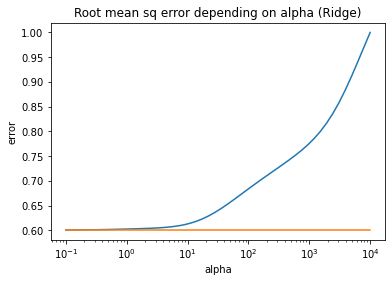

In [256]:
ax = plt.gca()

ax.plot(alphas, log_errors_Ridge)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Ridge)')
plt.show()

In [257]:
print('the minimal log_errors_Ridge is', min(log_errors_Ridge), 'in position', log_errors_Ridge.index(min(log_errors_Ridge)))
print('alpha parameter for the minimal error is', alphas[log_errors_Ridge.index(min(log_errors_Ridge))])

the minimal log_errors_Ridge is 0.6005471759317393 in position 0
alpha parameter for the minimal error is 0.1


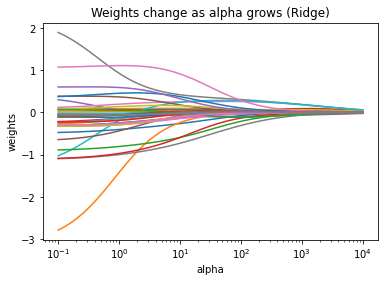

In [258]:
ax = plt.gca()

ax.plot(alphas, coefs_Ridge)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Ridge)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the ridge calculation below

### Lasso regression illustration: manual choice of alpha

In [259]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [260]:
n_alphas = 50
alphas = np.logspace(-5, 1, n_alphas)

lasso = Lasso()
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Lasso = []
log_errors_Lasso = []
for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X1, y_train['LogSiteEnergyUse'])
    coefs_Lasso.append(lasso.coef_)
#     log_errors_Lasso.append(np.mean((lasso.predict(X2) - y_test['LogSiteEnergyUse']) ** 2).values[0])
    log_errors_Lasso.append(np.sqrt(np.mean((lasso.predict(X2) - y_test['LogSiteEnergyUse']) ** 2)))
#     it's the way to calculate mean squared error

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 134.39913295014102, tolerance: 0.13088466080791925
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 132.66283773436373, tolerance: 0.13088466080791925
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 130.3888885769484, tolerance: 0.13088466080791925
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:53

Sometimes we see that the curve (Lasso error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Lasso Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

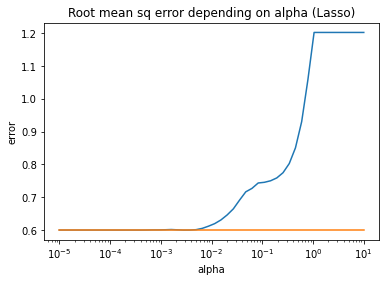

In [261]:
ax = plt.gca()

ax.plot(alphas, log_errors_Lasso)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Lasso)')
plt.show()

In [262]:
print('the minimal log_errors_Lasso is', min(log_errors_Lasso), 'in position', log_errors_Lasso.index(min(log_errors_Lasso)))
print('alpha parameter for the minimal error is', alphas[log_errors_Lasso.index(min(log_errors_Lasso))])

the minimal log_errors_Lasso is 0.6002722629593186 in position 20
alpha parameter for the minimal error is 0.002811768697974231


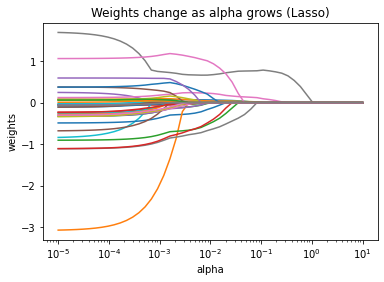

In [263]:
ax = plt.gca()

ax.plot(alphas, coefs_Lasso)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Lasso)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the lasso calculation below

### Ridge regression with cross-validation

In [264]:
param_test = {'alpha': np.logspace(0, 3, 10)}

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Ridge(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_ridge.py:555: UserWarning: "sag" solver requires many iterations to fit an intercept with sparse inputs. Either set the solver to "auto" or "sparse_cg", or set a low "tol" and a high "max_iter" (especially if inputs are not standardized).

'sag' solver was removed from the parameters grid.

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: 

I have just kept only 'auto' solver.

In [265]:
# tygdyk
model[1].best_params_

{'alpha': 2.154434690031884}

In [266]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Ridge'
optimal_params.append(['Ridge', param_stock])

In [267]:
y_pred = model.predict(X_test)

log_errors.append(['Ridge', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [268]:
log_errors.append(['Ridge', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [269]:
errors.append(['Ridge', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Lasso regression with cross-validation

In [270]:
param_test = {'alpha': np.logspace(-3, 3, 7),
#               'precompute': [False, True],  # default parameter False is better for all the test I did
             'selection': ['random', 'cyclic']}


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Lasso(tol=0.001, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

In [271]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'selection': 'cyclic'}

In [272]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Lasso'
optimal_params.append(['Lasso', param_stock])

In [273]:
y_pred = model.predict(X_test)

log_errors.append(['Lasso', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [274]:
log_errors.append(['Lasso', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [275]:
errors.append(['Lasso', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Elastic Net regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [276]:
param_test = {'alpha': np.logspace(-3, 3, 7),
             'l1_ratio': np.linspace(0.1, 0.9, 9),
#              'selection': ['random', 'cyclic']
             }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=ElasticNet(max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

for each of RMSE, MAE and R2 score

In [277]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'l1_ratio': 0.6}

In [278]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Elastic Net'
optimal_params.append(['Elastic Net', param_stock])

In [279]:
y_pred = model.predict(X_test)

log_errors.append(['ElasticNet', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [280]:
log_errors.append(['ElasticNet', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [281]:
errors.append(['ElasticNet', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Random Forest Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [282]:
param_test = {'n_estimators': [50, 100, 200, 400], # of 50,100,200,400 best value is 200
#              'criterion': ['mse', 'mae'],  # default value is mse
             'max_depth': [4, 6, 9, None], 
#              'min_samples_split': [2, 4],  # default value 2 is the best
#              'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#              'min_weight_fraction_leaffloat': [0], 
#              'max_features': ['auto', 'sqrt', 'log'], # default value 'auto' is the best, = n_features
#              'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
#              'min_impurity_decrease'[0], 
#              'verbose': [0],
#              'ccp_alpha': [0],  # should be non-negative
#              'max_samples': [None]  #if None, draw X.shape[0] samples
             }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=RandomForestRegressor(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:880: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

In [283]:
# tygdyk
model[1].best_params_

{'max_depth': 9, 'n_estimators': 400}

In [284]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [285]:
y_pred = model.predict(X_test)

log_errors.append(['Random_Forest', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [286]:
log_errors.append(['Random_Forest', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [287]:
errors.append(['Random_Forest', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Gradient Boosting Regressor with cross-validation

In [288]:
param_test = {'loss': ['ls', 'lad', 'huber', 'quantile'], # huber is the best
#               'learning_rate': [0.2, 0.1, 0.05], # default value 0.1 is best of 0.2, 0.1, 0.05
              'n_estimators': [100, 200, 400, 600], # of best value is 400, sometimes 200
              'max_depth': [4, 6, 9, None], # default value None is the best, sometimes 4
#               'subsample': [1.0, 0.9],
#               'min_samples_split': [2, 5, 10],  # default value 2 is the best
#               'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#               'min_weight_fraction_leaf': [0, 0.1], # default value 0 is the best
#               'max_features': ['auto', 'sqrt'], # default value 'auto' is the best, 'log' rises an error, model not converged
#               'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
              'min_impurity_decrease': [0.001, 0.01, 0.1, 1],  # best param varies from one click to another
              }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=GradientBoostingRegressor(n_iter_no_change=5, tol = 0.1), 
                          param_grid=param_test, 
                          cv=3, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

In [289]:
# tygdyk
model[1].best_params_

{'loss': 'ls',
 'max_depth': 4,
 'min_impurity_decrease': 0.01,
 'n_estimators': 100}

In [290]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Gradient Boosting Regressor', param_stock])

In [291]:
y_pred = model.predict(X_test)

log_errors.append(['Gradient_Boosting', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [292]:
log_errors.append(['Gradient_Boosting', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [293]:
errors.append(['Gradient_Boosting', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

###  XGB Regressor with cross-validation, Learning API

In [294]:
prepr_fitted = preprocessor1.fit(X_train)
X1 = prepr_fitted.transform(X_train)
X2 = prepr_fitted.transform(X_test)

dtrain = xgb.DMatrix(X1, label=y_train['LogSiteEnergyUse'])
dtest = xgb.DMatrix(X2, label=y_test['LogSiteEnergyUse'])

In [295]:
# guide for parameters tuning: https://blog.cambridgespark.com/hyperparameter-tuning-in-xgboost-4ff9100a3b2f
# notice the importance of the seed

params = {
    # Parameters that we are going to tune.
    'max_depth':6,
    'min_child_weight': 1,
    'eta':.3,
    'subsample': 1,
    'colsample_bytree': 1,
    # Other parameters
    'objective':'reg:squarederror',
    'eval_metric': ['rmse', 'mae']
}
num_boost_round = 999

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/objective/regression_obj.cu:171: reg:linear is now deprecated in favor of reg:squarederror.

In [296]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:10.22776	Test-mae:10.17325
[1]	Test-rmse:7.21538	Test-mae:7.15527
[2]	Test-rmse:5.10160	Test-mae:5.03098
[3]	Test-rmse:3.62345	Test-mae:3.54303
[4]	Test-rmse:2.59691	Test-mae:2.49437
[5]	Test-rmse:1.89148	Test-mae:1.77965
[6]	Test-rmse:1.41202	Test-mae:1.28925
[7]	Test-rmse:1.09576	Test-mae:0.96383
[8]	Test-rmse:0.89694	Test-mae:0.75059
[9]	Test-rmse:0.77330	Test-mae:0.61204
[10]	Test-rmse:0.70326	Test-mae:0.53689
[11]	Test-rmse:0.66579	Test-mae:0.49394
[12]	Test-rmse:0.64831	Test-mae:0.47677
[13]	Test-rmse:0.63129	Test-mae:0.45774
[14]	Test-rmse:0.62686	Test-mae:0.45229
[15]	Test-rmse:0.62468	Test-mae:0.44890
[16]	Test-rmse:0.62529	Test-mae:0.44995
[17]	Test-rmse:0.62646	Test-mae:0.45025
[18]	Test-rmse:0.62715	Test-mae:0.44863
[19]	Test-rmse:0.62766	Test-mae:0.44849
[20]	Test-rmse:0.62544	Test-mae:0.44604
[21]	Test-rmse:0.62406	Test-mae:0.44397
[22]	Test-rmse:0.62369	Test-mae:0.44443
[23]	Test-rmse:0.62323	Test-mae:0.44447
[24]	Test-rmse:0.62535	Test-mae:0.44487
[25]	Tes

In [297]:
print("Best MAE: {:.2f} with {} rounds".format(
                 model.best_score,
                 model.best_iteration+1))

Best MAE: 0.44 with 22 rounds


In [298]:
cv_results = xgb.cv(params, 
                    dtrain, 
                    num_boost_round=num_boost_round, 
                    seed=42, 
                    nfold=5, 
                    metrics={'rmse', 'mae'},  # 'r2' or 'r2score' doesn't exist
                    early_stopping_rounds=10)

In [299]:
cv_results['test-mae-mean'].min()

0.45947459999999996

In [300]:
gridsearch_params = [
    (max_depth, min_child_weight)
    for max_depth in (2,3,6)
    for min_child_weight in np.logspace(-8, 0, 3) #in range(5,8)
]

In [301]:
# Define initial best params and MAE
min_mae = float("Inf")
min_rmse = float("Inf")
# best_params = None

for max_depth, min_child_weight in gridsearch_params:
#     print("CV with max_depth={}, min_child_weight={}".format(
#                              max_depth,
#                              min_child_weight))
    # Update our parameters
    params['max_depth'] = max_depth
    params['min_child_weight'] = min_child_weight
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best MAE
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (max_depth,min_child_weight)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}, RMSE: {}".format(best_params[0], best_params[1], min_mae, min_rmse))

params['max_depth'] = best_params[0]
params['min_child_weight'] = best_params[1]

Best params: 3, 1e-08, MAE: 0.454093, RMSE: 0.6254046


In [302]:
gridsearch_params = [
    (subsample, colsample)
    for subsample in [i/10. for i in range(6,11,2)]
    for colsample in [i/10. for i in range(6,11,2)]
]

In [303]:
min_mae = float("Inf")
min_rmse = float("Inf")
best_params = None

# Start by the largest values and go down to the smallest
for subsample, colsample in reversed(gridsearch_params):
#     print("CV with subsample={}, colsample={}".format(
#                              subsample,
#                              colsample))

    # Update parameters
    params['subsample'] = subsample
    params['colsample_bytree'] = colsample
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (subsample,colsample)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}".format(best_params[0], best_params[1], min_mae))

params['subsample'] = best_params[0]
params['colsample_bytree'] = best_params[1]

Best params: 1.0, 0.6, MAE: 0.4533423999999999


In [304]:
%time
min_mae = float("Inf")
best_params = None
for eta in [.3, .2, .1, .05, .01, .005]:
#     print("CV with eta={}".format(eta))
    
    # Update parameters
    params['eta'] = eta
    # Run and time CV
    %time cv_results = xgb.cv(params,dtrain,num_boost_round=num_boost_round,seed=42,nfold=5,metrics=['rmse','mae'],early_stopping_rounds=10)
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-mae-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds\n".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = eta
    if mean_mae < min_mae:
        min_mae = mean_mae
print("Best params: {}, MAE: {}, RMSE: {}".format(best_params, min_mae, min_rmse))

params['eta'] = best_params

Wall time: 0 ns
Wall time: 176 ms
Wall time: 212 ms
Wall time: 380 ms
Wall time: 658 ms
Wall time: 3.14 s
Wall time: 3.77 s
Best params: 0.1, MAE: 0.4451032, RMSE: 0.6164118000000001


In [305]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:13.11530	Test-mae:13.06501
[1]	Test-rmse:11.81959	Test-mae:11.76795
[2]	Test-rmse:10.65298	Test-mae:10.59932
[3]	Test-rmse:9.60391	Test-mae:9.54898
[4]	Test-rmse:8.65990	Test-mae:8.60324
[5]	Test-rmse:7.81095	Test-mae:7.75091
[6]	Test-rmse:7.04955	Test-mae:6.98750
[7]	Test-rmse:6.36390	Test-mae:6.29838
[8]	Test-rmse:5.74571	Test-mae:5.67797
[9]	Test-rmse:5.19226	Test-mae:5.12084
[10]	Test-rmse:4.69372	Test-mae:4.61777
[11]	Test-rmse:4.24309	Test-mae:4.16345
[12]	Test-rmse:3.84117	Test-mae:3.75717
[13]	Test-rmse:3.47558	Test-mae:3.38698
[14]	Test-rmse:3.14889	Test-mae:3.05551
[15]	Test-rmse:2.85701	Test-mae:2.75631
[16]	Test-rmse:2.59267	Test-mae:2.48546
[17]	Test-rmse:2.35824	Test-mae:2.24491
[18]	Test-rmse:2.14886	Test-mae:2.03251
[19]	Test-rmse:1.96109	Test-mae:1.84370
[20]	Test-rmse:1.79355	Test-mae:1.67346
[21]	Test-rmse:1.64480	Test-mae:1.52276
[22]	Test-rmse:1.51141	Test-mae:1.38531
[23]	Test-rmse:1.39277	Test-mae:1.26417
[24]	Test-rmse:1.28782	Test-mae:1.15718
[25]

In [306]:
print("Best MAE: {:.2f} in {} rounds".format(model.best_score, model.best_iteration+1))

Best MAE: 0.43 in 111 rounds


In [307]:
num_boost_round = model.best_iteration + 1
best_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")])

[0]	Test-rmse:13.11530	Test-mae:13.06501
[1]	Test-rmse:11.81959	Test-mae:11.76795
[2]	Test-rmse:10.65298	Test-mae:10.59932
[3]	Test-rmse:9.60391	Test-mae:9.54898
[4]	Test-rmse:8.65990	Test-mae:8.60324
[5]	Test-rmse:7.81095	Test-mae:7.75091
[6]	Test-rmse:7.04955	Test-mae:6.98750
[7]	Test-rmse:6.36390	Test-mae:6.29838
[8]	Test-rmse:5.74571	Test-mae:5.67797
[9]	Test-rmse:5.19226	Test-mae:5.12084
[10]	Test-rmse:4.69372	Test-mae:4.61777
[11]	Test-rmse:4.24309	Test-mae:4.16345
[12]	Test-rmse:3.84117	Test-mae:3.75717
[13]	Test-rmse:3.47558	Test-mae:3.38698
[14]	Test-rmse:3.14889	Test-mae:3.05551
[15]	Test-rmse:2.85701	Test-mae:2.75631
[16]	Test-rmse:2.59267	Test-mae:2.48546
[17]	Test-rmse:2.35824	Test-mae:2.24491
[18]	Test-rmse:2.14886	Test-mae:2.03251
[19]	Test-rmse:1.96109	Test-mae:1.84370
[20]	Test-rmse:1.79355	Test-mae:1.67346
[21]	Test-rmse:1.64480	Test-mae:1.52276
[22]	Test-rmse:1.51141	Test-mae:1.38531
[23]	Test-rmse:1.39277	Test-mae:1.26417
[24]	Test-rmse:1.28782	Test-mae:1.15718
[25]

'num_boost_round': 200 in params raises an error:

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "num_boost_round" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.

In [308]:
y_pred = best_model.predict(dtest)
mean_absolute_error(y_pred, y_test)
np.sqrt(mean_squared_error(y_test, y_pred))

0.5972803921232396

In [309]:
y_pred = best_model.predict(dtest)

In [310]:
log_errors.append(['XGB_LearningAPI', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               9.999])

As XGBoost doesn't have R2 score in metrics in cross-validation, I calculate a train r2 score without cross-validation. 
Minimal RMSE and MAE can be found from cv_results dataframe, but the model has been updated since that: not only the parameters are optimized, but the number of iterations as well.

In [311]:
y_train_pred = best_model.predict(dtrain)

log_errors.append(['XGB_LearningAPI', 'from_train', 'without_score',
               round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 3),
               round(mean_absolute_error(y_train, y_train_pred), 3),
               round(r2_score(y_train, y_train_pred), 3),
#                model.score(X_train, y_train),
               9.999])

In [312]:
errors.append(['XGB_LearningAPI', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

###  XGB Regressor with cross-validation, SKLearn API (wrapper)

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [313]:
# question: is alpha_reg the same thing that alpha? and lambda_reg the same thing that lambda?

# params explained: https://towardsdatascience.com/xgboost-fine-tune-and-optimize-your-model-23d996fab663
# full list of params https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.sklearn
# parameters: general ones, and divided by subcategory: https://xgboost.readthedocs.io/en/latest/parameter.html

param_test = {
#            'max_depth': [3, 6, 10], # by default 6, and 6 have been shown the best
           'learning_rate': [0.01], # by default 0.3, [0.01, 0.3] 0.01 is better but much slower
           'n_estimators': [100, 500, 1000], # by default 100
#            'colsample_bytree': [0.3, 0.7], # default value 1 is the best
           'alpha': [0, 0.001, 0.01, 0.1],# by default 0, best shown 0.001
           'lambda': [1, 3, 5]  # default is 1, best shown 3 from 0.1,1,3
            }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=XGBRegressor(objective='reg:squarederror', base_score=y_train['LogSiteEnergyUse'].median()), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

In [314]:
# tygdyk
model[1].best_params_
# colsample_by_tree and n_estimators are maximal, max depth is by default 6
# {'colsample_bytree': 0.7,
#  'learning_rate': 0.01,
#  'max_depth': 6,
#  'n_estimators': 1000}

{'alpha': 0.01, 'lambda': 3, 'learning_rate': 0.01, 'n_estimators': 500}

In [315]:
param_stock = model[1].best_params_
# param_stock['name'] = 'XGBRegressor'
optimal_params.append(['XGBRegressor', param_stock])

In [316]:
param_stock

{'alpha': 0.01, 'lambda': 3, 'learning_rate': 0.01, 'n_estimators': 500}

In [317]:
# model[1].cv_results_ extremely long dictionary

In [318]:
y_pred = model.predict(X_test)

log_errors.append(['XGBRegressor', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [319]:
log_errors.append(['XGBRegressor', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [320]:
errors.append(['XGBRegressor', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### SGD Regressor with cross-validation (Stochastic Gradient Descent)

The gradient of the loss is estimated each sample at a time and the model is updated along the way with a decreasing strength schedule (aka learning rate).

The regularizer is a penalty added to the loss function that shrinks model parameters towards the zero vector using either the squared euclidean norm L2 or the absolute norm L1 or a combination of both (Elastic Net). If the parameter update crosses the 0.0 value because of the regularizer, the update is truncated to 0.0 to allow for learning sparse models and achieve online feature selection.

This implementation works with data represented as dense numpy arrays of floating point values for the features.

In [321]:
param_test = {
    'alpha': np.logspace(-3, 3, 7),
    'loss': ['squared_loss', 'huber'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
    'penalty': ['l2', 'l1', 'elasticnet'],
    'l1_ratio': [0.15, 0.5],
    'learning_rate': ['constant', 'invscaling', 'adaptive'], # default invscaling
    }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SGDRegressor(tol=0.001, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

In [322]:
# tygdyk
model[1].best_params_
# colsample_by_tree and n_estimators are maximal, max depth is by default 6
# {'colsample_bytree': 0.7,
#  'learning_rate': 0.01,
#  'max_depth': 6,
#  'n_estimators': 1000}

{'alpha': 0.1,
 'l1_ratio': 0.15,
 'learning_rate': 'adaptive',
 'loss': 'squared_loss',
 'penalty': 'l2'}

In [323]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SGDegressor'
optimal_params.append(['SGDegressor', param_stock])

In [324]:
y_pred = model.predict(X_test)

log_errors.append(['SGDRegressor', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [325]:
log_errors.append(['SGDRegressor', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [326]:
errors.append(['SGDRegressor', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### SV Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [327]:
param_test = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
#     kernel 'precomputed' raises an error: the precomputed kernel matrix must be used
    'C': [1, 10, 100] # default is 1, best is 5 from 0.2, 1, 5
    }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SVR(tol=0.001, max_iter=1_000_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogSiteEnergyUse'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

In [328]:
# tygdyk
model[1].best_params_

{'C': 10, 'kernel': 'linear'}

In [329]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SVR'
optimal_params.append(['SVR', param_stock])

In [330]:
y_pred = model.predict(X_test)

log_errors.append(['SVR', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [331]:
log_errors.append(['SVR', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [332]:
errors.append(['SVR', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

# Model performance comparison (synthesis table)

In [333]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [334]:
df_results = pd.DataFrame(errors,columns=['Model', 'Source', 'Variables', 'RMSE', 'MAE', 'R2Score', 'Fit time'])

In [335]:
# df_results = df_results_full.drop(['MAE', 'R2Score', 'Fit time'], axis=1)

In [336]:
log_results = pd.DataFrame(log_errors,columns=['Model', 'Source', 'Variables', 'RMSE', 'MAE', 'R2Score', 'Fit time'])

In [337]:
# display(df_results.sort_values(by='RMSE').head(10))
display(df_results[df_results.Source != 'from_train'].sort_values(by='RMSE').head())
display(df_results[df_results.Source == 'from_test'].sort_values(by='RMSE').head())
display(df_results[df_results.Source == 'from_log_test'].sort_values(by='RMSE').head())

,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
14,XGB_LearningAPI,from_test,with_score,3265780.392,1800057.656,0.880,9.999
30,XGBRegressor,from_log_test,with_score,3347262.865,1711075.055,0.874,0.015
27,Random_Forest,from_log_test,with_score,3507312.799,1704476.580,0.861,0.996
29,XGB_LearningAPI,from_log_test,with_score,3515748.145,1702342.351,0.861,0.015
16,XGBRegressor,from_test,with_score,3613731.260,1921797.793,0.853,1.187


,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
14,XGB_LearningAPI,from_test,with_score,3265780.392,1800057.656,0.880,9.999
16,XGBRegressor,from_test,with_score,3613731.260,1921797.793,0.853,1.187
12,Gradient_Boosting,from_test,with_score,3644982.690,1953811.829,0.850,0.087
49,XGBRegressor,from_test,without_score,3856970.060,2200948.520,0.832,3.577
10,Random_Forest,from_test,with_score,4090623.241,2102485.191,0.811,2.942


,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
30,XGBRegressor,from_log_test,with_score,3347262.865,1711075.055,0.874,0.015
27,Random_Forest,from_log_test,with_score,3507312.799,1704476.580,0.861,0.996
29,XGB_LearningAPI,from_log_test,with_score,3515748.145,1702342.351,0.861,0.015
63,XGBRegressor,from_log_test,without_score,4053397.401,2134613.691,0.815,0.012
60,Random_Forest,from_log_test,without_score,4172969.266,2174019.833,0.804,0.012


### And best model is:
#### With Energy Star score:
XGB_LearningAPI with Log Transform! (random_state of train_test_split=1) and SKLearn API no log, very close
Gradient Boosting! (random_state of train_test_split=2)
XGBRegressor (SKLearnAPI)! (random_state of train_test_split=3) 3rd place Gradient Boosting
XGBRegressor (SKLearnAPI)! (random_state of train_test_split=4) 3rd Random Forest wiht log
SGDRegressor with Log Transform! (random_state of train_test_split=5) 3rd Ridge wiht log
XGB_LearningAPI! (random_state of train_test_split=6) and SKLearn API no log, very close

Second place: 
XGBRegressor (SKLearnAPI)! (random_state of train_test_split=1) 3rd place SVR
XGB_LearningAPI! (random_state of train_test_split=2) 3rd placeXGB SKLearn very close
XGB_LearningAPI! (random_state of train_test_split=3) 3rd place Gradient Boosting very close
Random Forest! (random_state of train_test_split=4) 3rd place Gradient Boosting
SVR with log transform! (random_state of train_test_split=5) 
XGBRegressor (SKLearnAPI) with Log Transform! (random_state of train_test_split=6) 3rd place SVR

#### Without Energy Star score:
Random Forest with Log Transform! (random_state of train_test_split=1)
Ridge with Log Transform! (random_state of train_test_split=2) 
XGBRegressor (SKLearnAPI)! (random_state of train_test_split=3)
Random Forest with Log Transform! (random_state of train_test_split=4)
SGDRegressor with Log Transform! (random_state of train_test_split=5) 3rd ElasticNet wiht log
XGBRegressor (SKLearnAPI)! (random_state of train_test_split=6)

Second place: 
Random Forest! (random_state of train_test_split=1) 3rd Gradient Boosting no log
XGB Regressor Learning Api with Log Transform! (random_state of train_test_split=2)
XGB Regressor Learning Api! (random_state of train_test_split=3)
Random Forest! (random_state of train_test_split=4) 3rd Ridge with log
Ridge with Log Transform! (random_state of train_test_split=5)
XGBRegressor (SKLearnAPI) with Log Transform! (random_state of train_test_split=6)

In [338]:
without_score = df_results[df_results.Variables == 'without_score']

In [339]:
# display(without_score.sort_values(by='RMSE').head(15))
display(without_score[without_score.Source != 'from_train'].sort_values(by='RMSE').head())
display(without_score[without_score.Source == 'from_test'].sort_values(by='RMSE').head())
display(without_score[without_score.Source == 'from_log_test'].sort_values(by='RMSE').head())

,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
49,XGBRegressor,from_test,without_score,3856970.060,2200948.520,0.832,3.577
63,XGBRegressor,from_log_test,without_score,4053397.401,2134613.691,0.815,0.012
60,Random_Forest,from_log_test,without_score,4172969.266,2174019.833,0.804,0.012
45,Gradient_Boosting,from_test,without_score,4292041.902,2363790.655,0.792,3.213
47,XGB_LearningAPI,from_test,without_score,4322168.848,2349266.510,0.789,9.999


,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
49,XGBRegressor,from_test,without_score,3856970.060,2200948.520,0.832,3.577
45,Gradient_Boosting,from_test,without_score,4292041.902,2363790.655,0.792,3.213
47,XGB_LearningAPI,from_test,without_score,4322168.848,2349266.510,0.789,9.999
43,Random_Forest,from_test,without_score,4547681.548,2440003.323,0.767,1.441
37,Ridge,from_test,without_score,5050948.415,2986637.344,0.712,0.002


,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
63,XGBRegressor,from_log_test,without_score,4053397.401,2134613.691,0.815,0.012
60,Random_Forest,from_log_test,without_score,4172969.266,2174019.833,0.804,0.012
62,XGB_LearningAPI,from_log_test,without_score,4498249.882,2297340.081,0.772,0.012
59,ElasticNet,from_log_test,without_score,4550154.838,2310663.267,0.767,0.012
58,Lasso,from_log_test,without_score,4560267.946,2313921.426,0.766,0.012


## Performance with or without LogTransformation of Targets

In [340]:
savepath = 'C:\\Users\\Veronika\\Dropbox\\OpenClassrooms\\SupP4RandState6\\'

With EnergyStar score

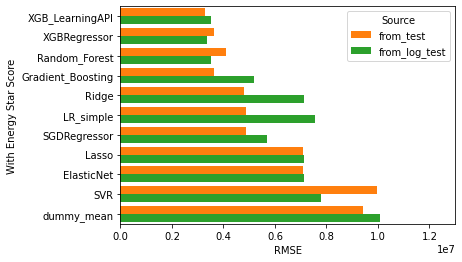

In [341]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_test', 'from_log_test'],
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source != 'from_train')].sort_values('RMSE'), 
                 palette = ['tab:orange', 'tab:green'], saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('With Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('With Energy Star Score')
plt.savefig(savepath+'001', bbox_inches='tight')

Without EnergyStar score

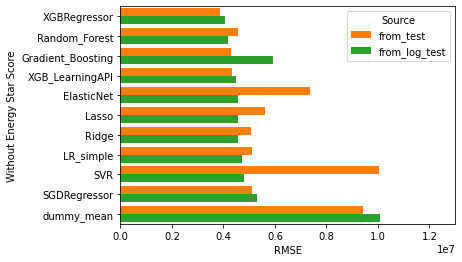

In [342]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_test', 'from_log_test'],
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source != 'from_train')].sort_values('RMSE'), 
                 palette = ['tab:orange', 'tab:green'], saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('Without Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('Without Energy Star Score')
plt.savefig(savepath+'002', bbox_inches='tight')

Which models are overfitted?

If we see a big difference, that the train error is much lower than the test error, it means model is overfitted.

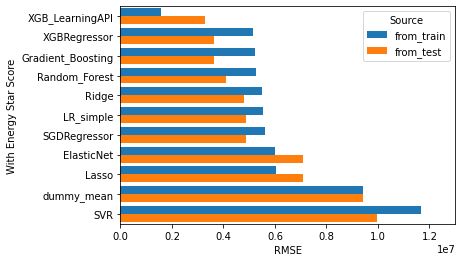

In [343]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_train', 'from_test'],
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source != 'from_log_test')].sort_values('RMSE'), 
                 palette = ['tab:blue', 'tab:orange'], saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('With Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('With Energy Star Score')
plt.savefig(savepath+'003', bbox_inches='tight')

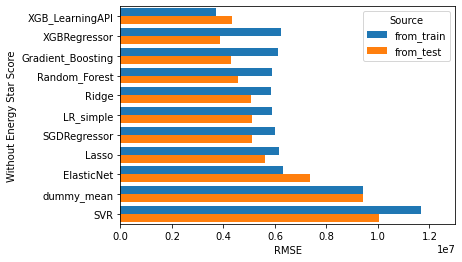

In [344]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_train', 'from_test'],
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source != 'from_log_test')].sort_values('RMSE'), 
                 palette = ['tab:blue', 'tab:orange'], saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('Without Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('Without Energy Star Score')
plt.savefig(savepath+'004', bbox_inches='tight')

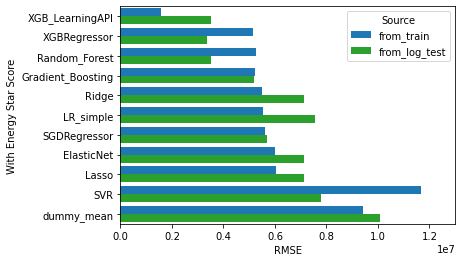

In [345]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_train', 'from_log_test'],
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source != 'from_test')].sort_values('RMSE'), 
                 palette = ['tab:blue', 'tab:green'], saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('With Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('With Energy Star Score')
plt.savefig(savepath+'005', bbox_inches='tight')

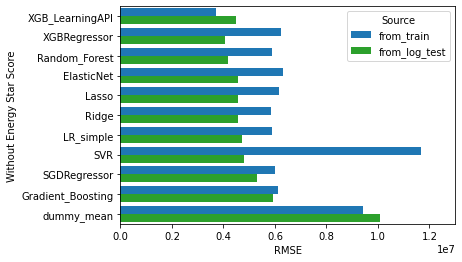

In [346]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_train', 'from_log_test'],
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source != 'from_test')].sort_values('RMSE'), 
                 palette = ['tab:blue', 'tab:green'], saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('Without Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('Without Energy Star Score')
plt.savefig(savepath+'006', bbox_inches='tight')

With logarithm transform RMS errors are lower. Let's see what's the best model 

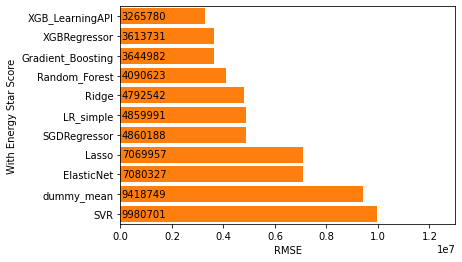

In [347]:
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source == 'from_test')].sort_values('RMSE') 

ax = sns.barplot(x='RMSE', y='Model',
                 data=data,
                 color='tab:orange', saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('With Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('With Energy Star Score')
for i, v in enumerate(data.RMSE):
    ax.text(50000, i + .15, str(int(v)))
plt.savefig(savepath+'007', bbox_inches='tight')

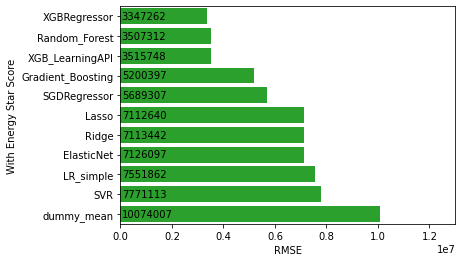

In [348]:
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source == 'from_log_test')].sort_values('RMSE')

ax = sns.barplot(x='RMSE', y='Model', data=data,
                 color='tab:green', saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('With Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('With Energy Star Score')
for i, v in enumerate(data.RMSE):
    ax.text(50000, i + .15, str(int(v)))
plt.savefig(savepath+'008', bbox_inches='tight')

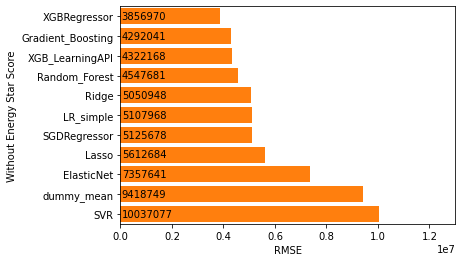

In [349]:
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source == 'from_test')].sort_values('RMSE')

ax = sns.barplot(x='RMSE', y='Model', data=data,
                 color='tab:orange', saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('Without Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('Without Energy Star Score')
for i, v in enumerate(data.RMSE):
    ax.text(50000, i + .15, str(int(v)))
plt.savefig(savepath+'009', bbox_inches='tight')

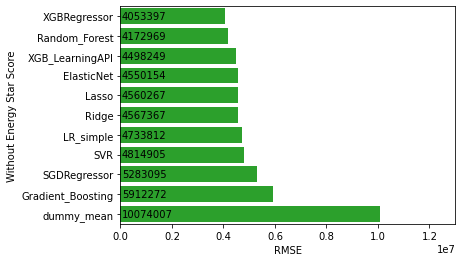

In [350]:
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source == 'from_log_test')].sort_values('RMSE')

ax = sns.barplot(x='RMSE', y='Model', data=data,
                 color='tab:green', saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('Without Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('Without Energy Star Score')
for i, v in enumerate(data.RMSE):
    ax.text(50000, i + .15, str(int(v)))
plt.savefig(savepath+'010', bbox_inches='tight')

## Performance with or without EnergyStarScore

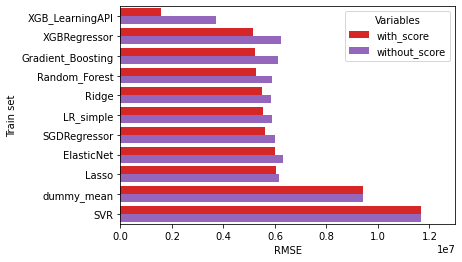

In [351]:
ax = sns.barplot(x='RMSE', y='Model', hue='Variables', hue_order=['with_score', 'without_score'],
                 data=df_results[df_results.Source == 'from_train'].sort_values('RMSE'),
                 palette = ['tab:red', 'tab:purple'], saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('Train set')
# ax.set_ylabel(None)
# ax.set_title('Train set')
plt.savefig(savepath+'011', bbox_inches='tight')

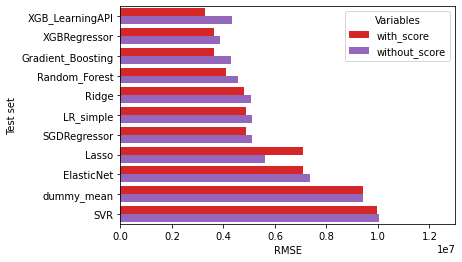

In [352]:
ax = sns.barplot(x='RMSE', y='Model', hue='Variables', hue_order=['with_score', 'without_score'],
                 data=df_results[df_results.Source == 'from_test'].sort_values('RMSE'),
                 palette = ['tab:red', 'tab:purple'], saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('Test set')
# ax.set_ylabel(None)
# ax.set_title('Test set')
plt.savefig(savepath+'012', bbox_inches='tight')

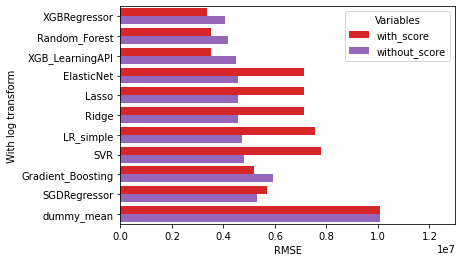

In [353]:
ax = sns.barplot(x='RMSE', y='Model', hue='Variables', hue_order=['with_score', 'without_score'],
                 data=df_results[df_results.Source == 'from_log_test'].sort_values('RMSE'),
                 palette = ['tab:red', 'tab:purple'], saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('With log transform')
# ax.set_ylabel(None)
# ax.set_title('With log transform')
plt.savefig(savepath+'013', bbox_inches='tight')

With EnergyStarScore errors are lower. Let's see what's the best model 

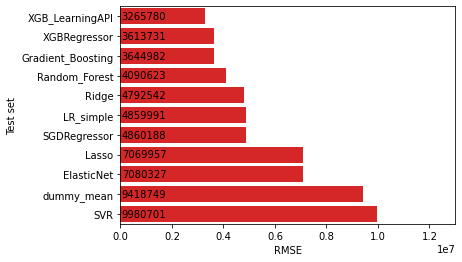

In [354]:
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source == 'from_test')].sort_values('RMSE')

ax = sns.barplot(x='RMSE', y='Model', data=data,
                 color='tab:red', saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('Test set')
# ax.set_ylabel(None)
# ax.set_title('Test set')
for i, v in enumerate(data.RMSE):
    ax.text(50000, i + .15, str(int(v)))
plt.savefig(savepath+'014', bbox_inches='tight')

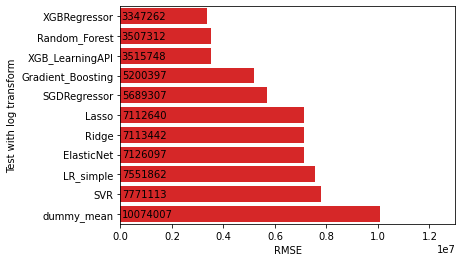

In [355]:
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source == 'from_log_test')].sort_values('RMSE')

ax = sns.barplot(x='RMSE', y='Model', data=data,
                 color='tab:red', saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('Test with log transform')
# ax.set_ylabel(None)
# ax.set_title('Test with log transform')
for i, v in enumerate(data.RMSE):
    ax.text(50000, i + .15, str(int(v)))
plt.savefig(savepath+'015', bbox_inches='tight')

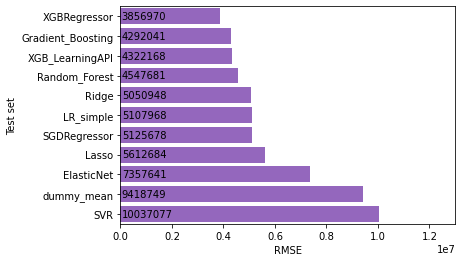

In [356]:
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source == 'from_test')].sort_values('RMSE') 

ax = sns.barplot(x='RMSE', y='Model', data=data,
                 color='tab:purple', saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('Test set')
# ax.set_ylabel(None)
# ax.set_title('Test set')
for i, v in enumerate(data.RMSE):
    ax.text(50000, i + .15, str(int(v)))
plt.savefig(savepath+'016', bbox_inches='tight')

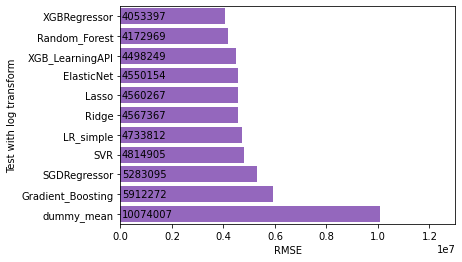

In [357]:
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source == 'from_log_test')].sort_values('RMSE')

ax = sns.barplot(x='RMSE', y='Model', data=data,
                 color='tab:purple', saturation=1)
ax.set_xlim(0, 1.3e7)
ax.set_ylabel('Test with log transform')
# ax.set_ylabel(None)
# ax.set_title('Test with log transform')
for i, v in enumerate(data.RMSE):
    ax.text(50000, i + .15, str(int(v)))
plt.savefig(savepath+'017', bbox_inches='tight')

### Individual graphics for models

In [358]:
df_results['SourceVariables'] = df_results['Source'] + ', ' + df_results['Variables']

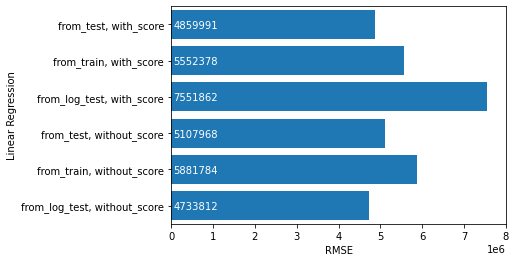

In [359]:
selection = df_results[df_results.Model == 'LR_simple']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Linear Regression')
ax.set_xlim(0, 0.8e7)
for i, v in enumerate(selection.RMSE):
    ax.text(50000, i + 0.1, str(int(v)), color='white')
plt.savefig(savepath+'018', bbox_inches='tight')

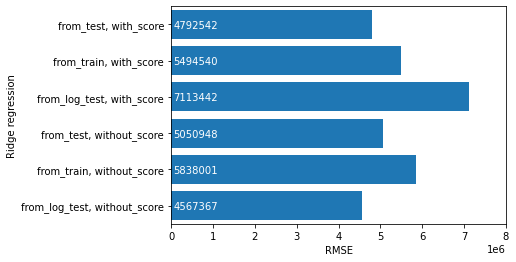

In [360]:
selection = df_results[df_results.Model == 'Ridge']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Ridge regression')
ax.set_xlim(0, 0.8e7)
for i, v in enumerate(selection.RMSE):
    ax.text(50000, i + 0.1, str(int(v)), color='white')
plt.savefig(savepath+'019', bbox_inches='tight')

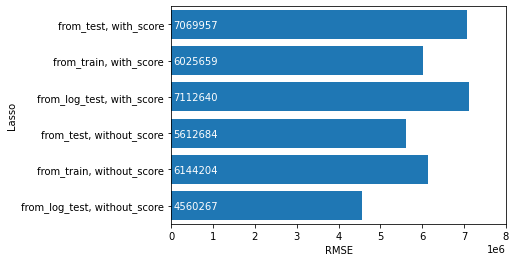

In [361]:
selection = df_results[df_results.Model == 'Lasso']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Lasso')
ax.set_xlim(0, 0.8e7)
for i, v in enumerate(selection.RMSE):
    ax.text(50000, i + 0.1, str(int(v)), color='white')
plt.savefig(savepath+'020', bbox_inches='tight')

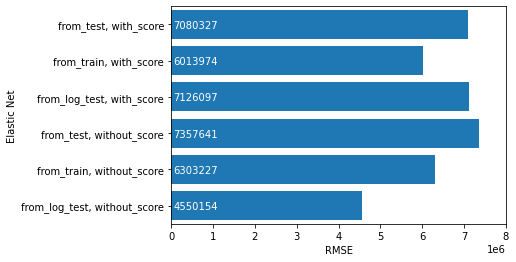

In [362]:
selection = df_results[df_results.Model == 'ElasticNet']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Elastic Net')
ax.set_xlim(0, 0.8e7)
for i, v in enumerate(selection.RMSE):
    ax.text(50000, i + 0.1, str(int(v)), color='white')
plt.savefig(savepath+'021', bbox_inches='tight')

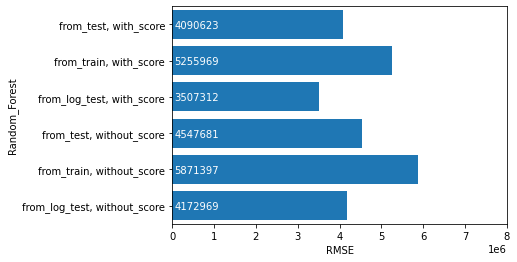

In [363]:
selection = df_results[df_results.Model == 'Random_Forest']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Random_Forest')
ax.set_xlim(0, 0.8e7)
for i, v in enumerate(selection.RMSE):
    ax.text(50000, i + 0.1, str(int(v)), color='white')
plt.savefig(savepath+'022', bbox_inches='tight')

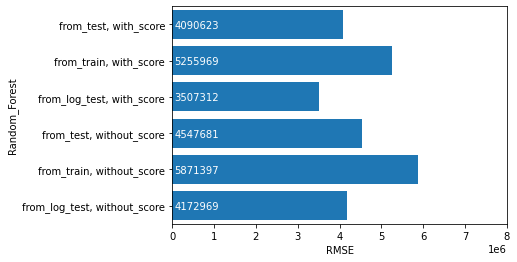

In [364]:
selection = df_results[df_results.Model == 'Random_Forest']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Random_Forest')
ax.set_xlim(0, 0.8e7)
for i, v in enumerate(selection.RMSE):
    ax.text(50000, i + 0.1, str(int(v)), color='white')
plt.savefig(savepath+'023', bbox_inches='tight')

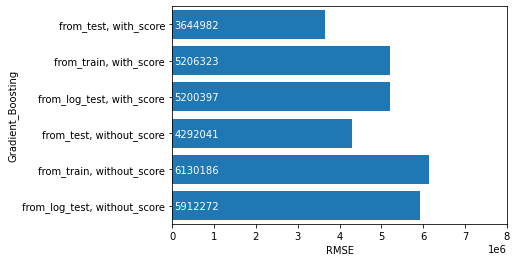

In [365]:
selection = df_results[df_results.Model == 'Gradient_Boosting']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Gradient_Boosting')
ax.set_xlim(0, 0.8e7)
for i, v in enumerate(selection.RMSE):
    ax.text(50000, i + 0.1, str(int(v)), color='white')
plt.savefig(savepath+'024', bbox_inches='tight')

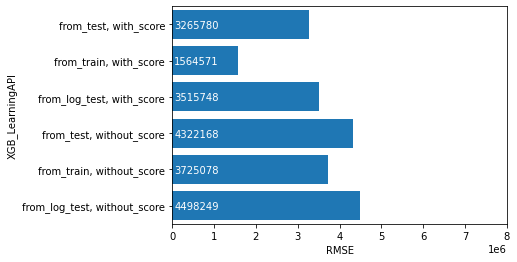

In [366]:
selection = df_results[df_results.Model == 'XGB_LearningAPI']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('XGB_LearningAPI')
ax.set_xlim(0, 0.8e7)
for i, v in enumerate(selection.RMSE):
    ax.text(50000, i + 0.1, str(int(v)), color='white')
plt.savefig(savepath+'025', bbox_inches='tight')

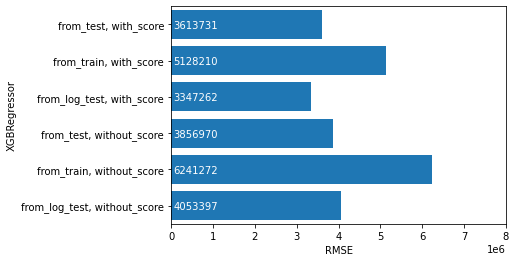

In [367]:
selection = df_results[df_results.Model == 'XGBRegressor']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('XGBRegressor')
ax.set_xlim(0, 0.8e7)
for i, v in enumerate(selection.RMSE):
    ax.text(50000, i + 0.1, str(int(v)), color='white')
plt.savefig(savepath+'026', bbox_inches='tight')

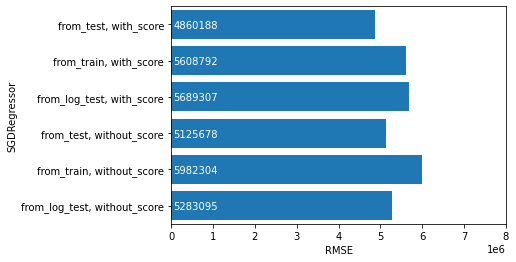

In [368]:
selection = df_results[df_results.Model == 'SGDRegressor']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('SGDRegressor')
ax.set_xlim(0, 0.8e7)
for i, v in enumerate(selection.RMSE):
    ax.text(50000, i + 0.1, str(int(v)), color='white')
plt.savefig(savepath+'027', bbox_inches='tight')

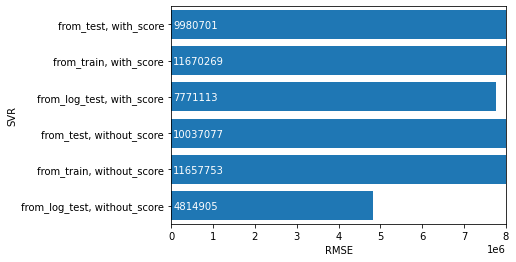

In [369]:
selection = df_results[df_results.Model == 'SVR']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('SVR')
ax.set_xlim(0, 0.8e7)
for i, v in enumerate(selection.RMSE):
    ax.text(50000, i + 0.1, str(int(v)), color='white')
plt.savefig(savepath+'028', bbox_inches='tight')